In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

master_file = (
    project_root
    / "data"
    / "processed"
    / "retailiq_cleaned_master.csv.gz"
)

master_df = pd.read_csv(
    master_file,
    parse_dates=["InvoiceDate"],
    low_memory=False
)

print("Master shape:", master_df.shape)
print(
    "Date range:",
    master_df["InvoiceDate"].min(),
    "to",
    master_df["InvoiceDate"].max()
)

Master shape: (1033036, 29)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


In [176]:
current_directory = Path.cwd()

project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)

forecasting_figure_dir = (
    project_root
    / "reports"
    / "figures"
    / "revenue_forecasting"
)

forecasting_figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Figures will be saved to:")
print(forecasting_figure_dir)

Figures will be saved to:
c:\Github\retail-financial-intelligence\reports\figures\revenue_forecasting


In [11]:
required_columns = {
    "Invoice",
    "StockCodeNormalized",
    "Quantity",
    "InvoiceDate",
    "Price",
    "Revenue",
    "TransactionType",
    "DQ_CriticalMissing",
    "IsExactReversalPair"
}

missing_columns = (
    required_columns
    - set(master_df.columns)
)

assert not missing_columns, (
    f"Missing columns: {missing_columns}"
)

print("Required forecasting columns validated.")

Required forecasting columns validated.


In [12]:
forecast_sales_df = master_df.loc[
    master_df["TransactionType"].eq("Sale")
    & master_df["Quantity"].gt(0)
    & master_df["Price"].gt(0)
    & master_df["Revenue"].gt(0)
    & ~master_df[
        "DQ_CriticalMissing"
    ].fillna(False)
    & ~master_df[
        "IsExactReversalPair"
    ].fillna(False)
].copy()

print(
    "Eligible sales rows:",
    f"{len(forecast_sales_df):,}"
)

Eligible sales rows: 997,418


In [13]:
dataset_end = (
    forecast_sales_df["InvoiceDate"]
    .max()
)

final_month = dataset_end.to_period("M")

final_month_is_complete = bool(
    dataset_end.normalize()
    >= final_month.end_time.normalize()
)

if final_month_is_complete:
    last_complete_month = final_month
else:
    last_complete_month = final_month - 1

forecast_end_date = (
    last_complete_month
    .end_time
    .normalize()
)

forecast_sales_df = forecast_sales_df.loc[
    forecast_sales_df["InvoiceDate"]
    .dt.normalize()
    <= forecast_end_date
].copy()

print(
    "Last complete month:",
    last_complete_month
)

print(
    "Forecasting data ends:",
    forecast_end_date.date()
)

Last complete month: 2011-11
Forecasting data ends: 2011-11-30


In [14]:
forecast_sales_df["SalesDate"] = (
    forecast_sales_df["InvoiceDate"]
    .dt.normalize()
)

daily_sales = (
    forecast_sales_df
    .groupby("SalesDate")
    .agg(
        Revenue=("Revenue", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("Invoice", "nunique"),
        UniqueProducts=(
            "StockCodeNormalized",
            "nunique"
        )
    )
    .sort_index()
)

In [15]:
complete_date_index = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D"
)

daily_sales = (
    daily_sales
    .reindex(
        complete_date_index,
        fill_value=0
    )
)

daily_sales.index.name = "SalesDate"

daily_sales = (
    daily_sales
    .reset_index()
)

In [16]:
assert daily_sales[
    "SalesDate"
].is_monotonic_increasing

assert daily_sales[
    "SalesDate"
].duplicated().sum() == 0

assert daily_sales[
    "Revenue"
].ge(0).all()

print("Daily observations:", len(daily_sales))
print(
    "Daily date range:",
    daily_sales["SalesDate"].min(),
    "to",
    daily_sales["SalesDate"].max()
)

daily_sales.head()

Daily observations: 730
Daily date range: 2009-12-01 00:00:00 to 2011-11-30 00:00:00


,SalesDate,Revenue,UnitsSold,Orders,UniqueProducts
0,2009-12-01,51865.67,25662,117,1307
1,2009-12-02,61748.60,31777,115,1388
2,2009-12-03,70453.87,47640,121,1318
3,2009-12-04,39193.02,21127,88,1246
4,2009-12-05,9578.78,4862,30,281


Time-series frequency analysis
Add rolling and calendar features

In [17]:
daily_sales = (
    daily_sales
    .sort_values("SalesDate")
    .reset_index(drop=True)
)

daily_sales["Revenue7DayAverage"] = (
    daily_sales["Revenue"]
    .rolling(
        window=7,
        min_periods=1
    )
    .mean()
)

daily_sales["DayOfWeek"] = (
    daily_sales["SalesDate"]
    .dt.day_name()
)

Create a complete-week dataset

In [18]:
weekly_sales = (
    daily_sales
    .assign(
        WeekStart=(
            daily_sales["SalesDate"]
            .dt.to_period("W-SUN")
            .dt.start_time
        )
    )
    .groupby("WeekStart")
    .agg(
        Revenue=("Revenue", "sum"),
        UnitsSold=("UnitsSold", "sum"),
        Orders=("Orders", "sum"),
        AverageDailyRevenue=("Revenue", "mean"),
        DaysObserved=("SalesDate", "size")
    )
    .reset_index()
)

# Exclude incomplete boundary weeks
complete_weekly_sales = weekly_sales.loc[
    weekly_sales["DaysObserved"].eq(7)
].copy()

print(
    "Daily observations:",
    len(daily_sales)
)

print(
    "Complete weekly observations:",
    len(complete_weekly_sales)
)

Daily observations: 730
Complete weekly observations: 103


Compare variability

In [19]:
frequency_diagnostics = pd.Series({
    "Daily observations":
        len(daily_sales),

    "Complete weekly observations":
        len(complete_weekly_sales),

    "Zero-sales days":
        daily_sales["Revenue"].eq(0).sum(),

    "Zero-sales days (%)":
        daily_sales["Revenue"].eq(0).mean() * 100,

    "Average daily revenue":
        daily_sales["Revenue"].mean(),

    "Median daily revenue":
        daily_sales["Revenue"].median(),

    "Daily coefficient of variation":
        (
            daily_sales["Revenue"].std()
            / daily_sales["Revenue"].mean()
        ),

    "Average weekly revenue":
        complete_weekly_sales[
            "Revenue"
        ].mean(),

    "Weekly coefficient of variation":
        (
            complete_weekly_sales[
                "Revenue"
            ].std()
            / complete_weekly_sales[
                "Revenue"
            ].mean()
        )
})

frequency_diagnostics.round(3)

Daily observations                    730.000
Complete weekly observations          103.000
Zero-sales days                       134.000
Zero-sales days (%)                    18.356
Average daily revenue               25552.845
Median daily revenue                24436.105
Daily coefficient of variation          0.741
Average weekly revenue             176880.345
Weekly coefficient of variation         0.400
dtype: float64

Check recurring patterns

In [20]:
lag_correlations = pd.Series({
    "Lag 1 day":
        daily_sales["Revenue"].autocorr(1),

    "Lag 7 days":
        daily_sales["Revenue"].autocorr(7),

    "Lag 14 days":
        daily_sales["Revenue"].autocorr(14),

    "Lag 28 days":
        daily_sales["Revenue"].autocorr(28),

    "Lag 365 days":
        daily_sales["Revenue"].autocorr(365)
})

lag_correlations.round(3)

Lag 1 day       0.423
Lag 7 days      0.654
Lag 14 days     0.565
Lag 28 days     0.511
Lag 365 days    0.463
dtype: float64

In [21]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_profile = (
    daily_sales
    .groupby("DayOfWeek")
    .agg(
        AverageRevenue=("Revenue", "mean"),
        MedianRevenue=("Revenue", "median"),
        AverageOrders=("Orders", "mean"),
        ZeroSalesDays=(
            "Revenue",
            lambda values: values.eq(0).sum()
        )
    )
    .reindex(weekday_order)
)

weekday_profile.round(2)

,AverageRevenue,MedianRevenue,AverageOrders,ZeroSalesDays
DayOfWeek,,,,
Monday,31470.57,26842.00,58.44,11
Tuesday,35112.55,29805.93,66.53,2
Wednesday,31147.61,28234.77,66.39,2
Thursday,36601.19,32636.05,75.62,3
Friday,27554.71,25443.93,55.62,7
Saturday,92.10,0.00,0.29,103
Sunday,16745.46,16602.35,45.58,6


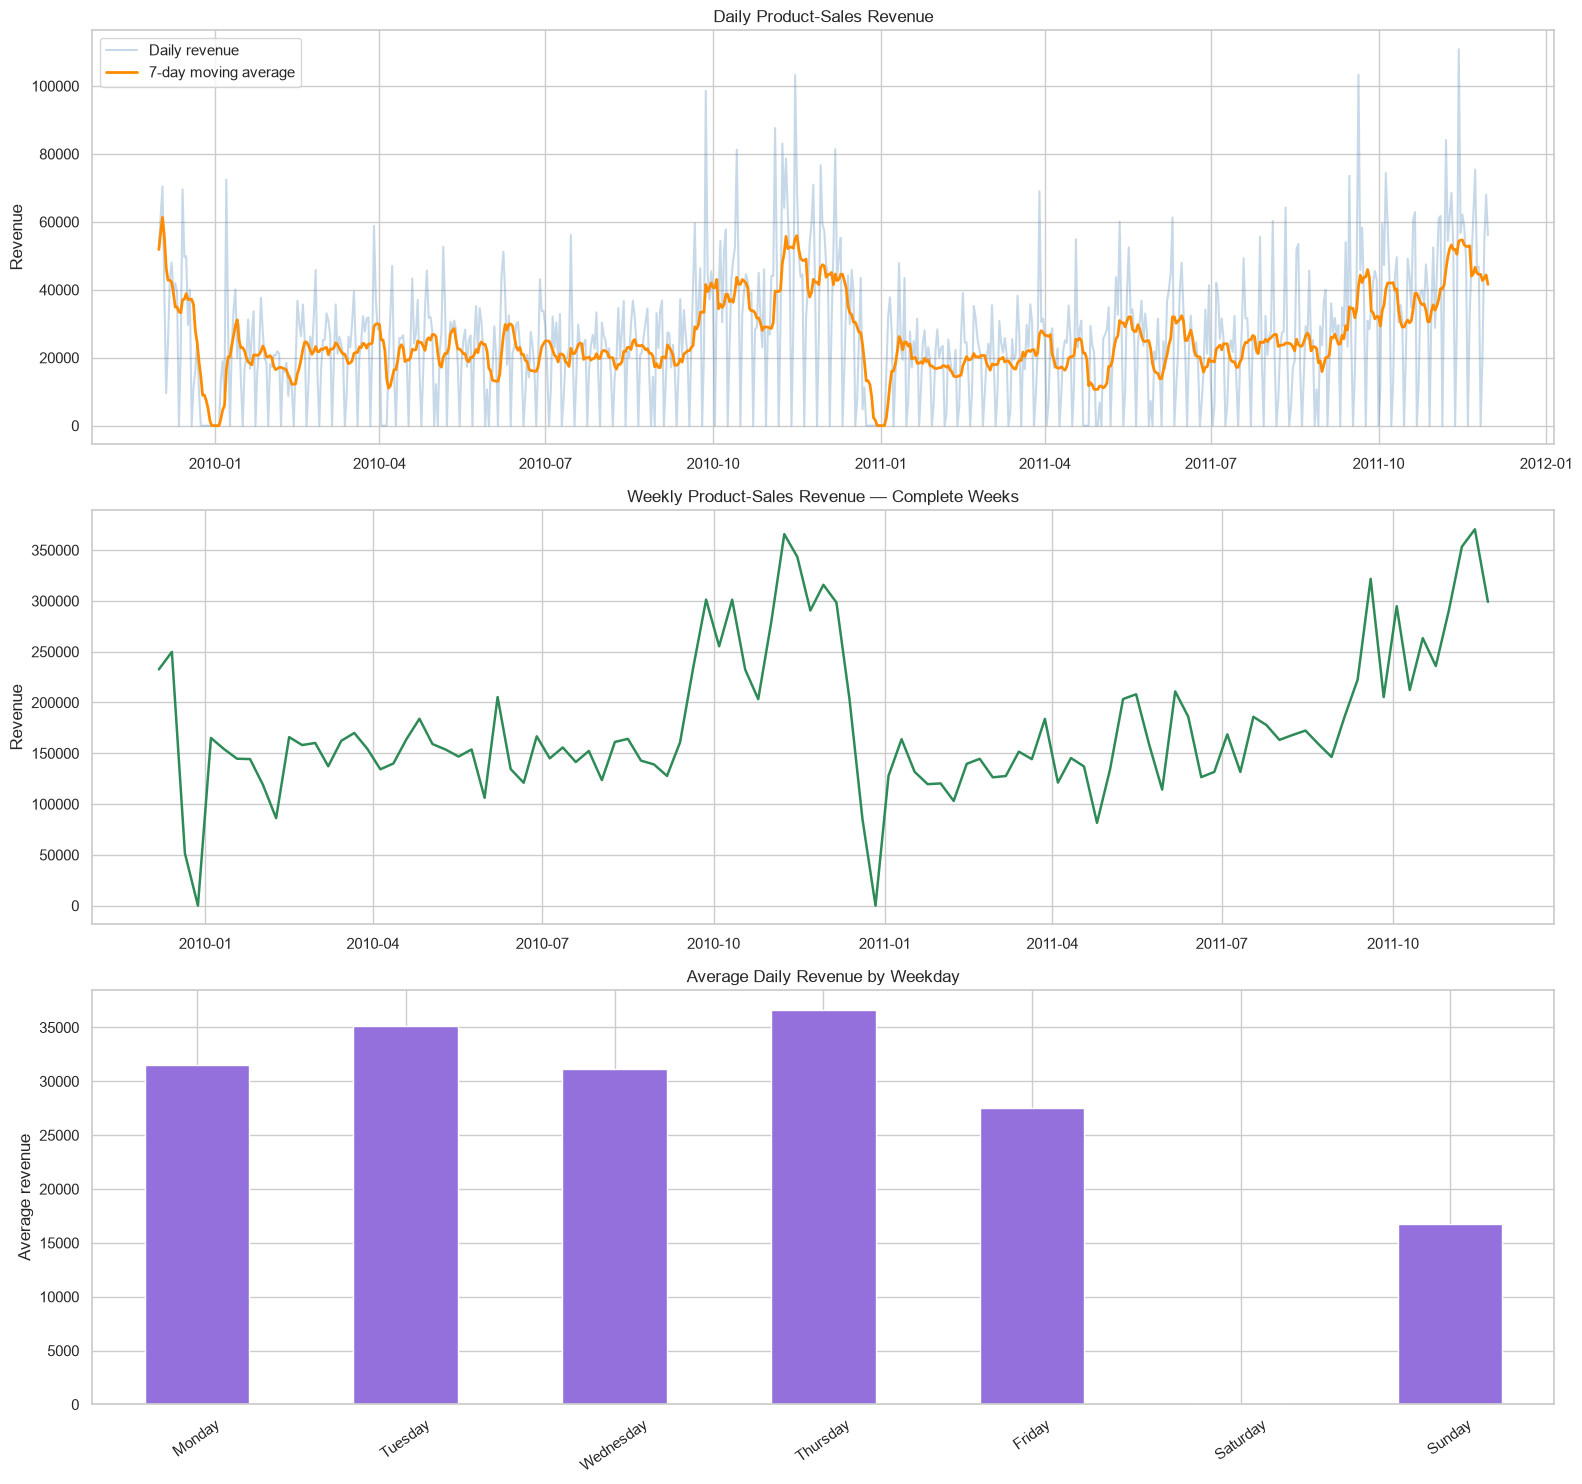

In [ ]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(16, 15)
)

axes[0].plot(
    daily_sales["SalesDate"],
    daily_sales["Revenue"],
    alpha=0.30,
    color="steelblue",
    label="Daily revenue"
)

axes[0].plot(
    daily_sales["SalesDate"],
    daily_sales["Revenue7DayAverage"],
    color="darkorange",
    linewidth=2,
    label="7-day moving average"
)

axes[0].set_title(
    "Daily Product-Sales Revenue"
)
axes[0].set_ylabel("Revenue")
axes[0].legend()

axes[1].plot(
    complete_weekly_sales["WeekStart"],
    complete_weekly_sales["Revenue"],
    color="seagreen",
    linewidth=1.8
)

axes[1].set_title(
    "Weekly Product-Sales Revenue — Complete Weeks"
)
axes[1].set_ylabel("Revenue")

weekday_profile[
    "AverageRevenue"
].plot(
    kind="bar",
    ax=axes[2],
    color="mediumpurple"
)

axes[2].set_title(
    "Average Daily Revenue by Weekday"
)
axes[2].set_xlabel("")
axes[2].set_ylabel("Average revenue")
axes[2].tick_params(
    axis="x",
    rotation=35
)

plt.tight_layout()

plt.savefig(
    forecasting_figure_dir / "daily_product_sales_revenue.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

In [23]:
forecast_validation_start = pd.Timestamp(
    "2011-06-01"
)

forecast_test_start = pd.Timestamp(
    "2011-09-01"
)

In [24]:
forecast_train_df = daily_sales.loc[
    daily_sales["SalesDate"]
    < forecast_validation_start
].copy()

forecast_validation_df = daily_sales.loc[
    daily_sales["SalesDate"].between(
        forecast_validation_start,
        forecast_test_start,
        inclusive="left"
    )
].copy()

forecast_test_df = daily_sales.loc[
    daily_sales["SalesDate"]
    >= forecast_test_start
].copy()

In [25]:
assert (
    forecast_train_df["SalesDate"].max()
    < forecast_validation_df["SalesDate"].min()
)

assert (
    forecast_validation_df["SalesDate"].max()
    < forecast_test_df["SalesDate"].min()
)

assert (
    len(forecast_train_df)
    + len(forecast_validation_df)
    + len(forecast_test_df)
    == len(daily_sales)
)

assert forecast_test_df[
    "SalesDate"
].max().month == 11

print("No chronological overlap.")

No chronological overlap.


In [26]:
forecast_split_summary = pd.DataFrame({
    "Dataset": [
        "Train",
        "Validation",
        "Test"
    ],
    "StartDate": [
        forecast_train_df[
            "SalesDate"
        ].min(),
        forecast_validation_df[
            "SalesDate"
        ].min(),
        forecast_test_df[
            "SalesDate"
        ].min()
    ],
    "EndDate": [
        forecast_train_df[
            "SalesDate"
        ].max(),
        forecast_validation_df[
            "SalesDate"
        ].max(),
        forecast_test_df[
            "SalesDate"
        ].max()
    ],
    "Days": [
        len(forecast_train_df),
        len(forecast_validation_df),
        len(forecast_test_df)
    ],
    "TotalRevenue": [
        forecast_train_df["Revenue"].sum(),
        forecast_validation_df[
            "Revenue"
        ].sum(),
        forecast_test_df["Revenue"].sum()
    ],
    "AverageDailyRevenue": [
        forecast_train_df["Revenue"].mean(),
        forecast_validation_df[
            "Revenue"
        ].mean(),
        forecast_test_df["Revenue"].mean()
    ]
})

forecast_split_summary.round(2)

C:\Users\anude\AppData\Local\Temp\ipykernel_17720\679424277.py:50: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  forecast_split_summary.round(2)


,Dataset,StartDate,EndDate,Days,TotalRevenue,AverageDailyRevenue
0,Train,2009-12-01,2011-05-31,547,12999597.56,23765.26
1,Validation,2011-06-01,2011-08-31,92,2127090.84,23120.55
2,Test,2011-09-01,2011-11-30,91,3526888.10,38757.01


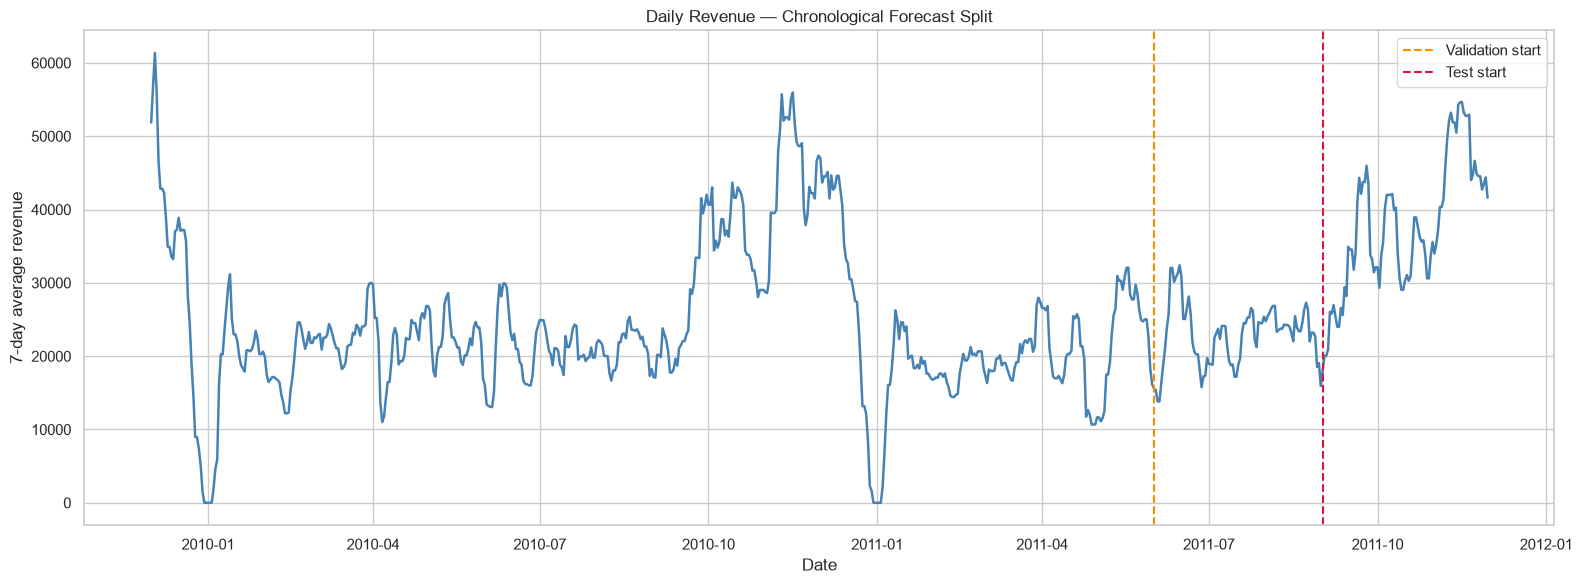

In [168]:
plt.figure(figsize=(16, 6))

plt.plot(
    daily_sales["SalesDate"],
    daily_sales["Revenue7DayAverage"],
    color="steelblue",
    linewidth=1.8
)

plt.axvline(
    forecast_validation_start,
    color="darkorange",
    linestyle="--",
    label="Validation start"
)

plt.axvline(
    forecast_test_start,
    color="crimson",
    linestyle="--",
    label="Test start"
)

plt.title(
    "Daily Revenue — Chronological Forecast Split"
)

plt.xlabel("Date")
plt.ylabel("7-day average revenue")
plt.legend()
plt.tight_layout()

plt.savefig(
    segmentation_figure_dir / "dail_revenue_chronological_forecast_split.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

Baseline forecasting models
Create baseline predictions

In [28]:
forecast_baseline_df = (
    daily_sales
    .sort_values("SalesDate")
    .reset_index(drop=True)
    .copy()
)

# Yesterday's revenue
forecast_baseline_df[
    "PreviousDayBaseline"
] = forecast_baseline_df[
    "Revenue"
].shift(1)

# Revenue on the same weekday one week earlier
forecast_baseline_df[
    "SeasonalNaive7Day"
] = forecast_baseline_df[
    "Revenue"
].shift(7)

# Average of the previous seven days
forecast_baseline_df[
    "MovingAverage7Day"
] = (
    forecast_baseline_df[
        "Revenue"
    ]
    .shift(1)
    .rolling(7)
    .mean()
)

# Average of the same weekday during the previous four weeks
same_weekday_lags = pd.concat(
    [
        forecast_baseline_df[
            "Revenue"
        ].shift(lag)
        for lag in [7, 14, 21, 28]
    ],
    axis=1
)

forecast_baseline_df[
    "SameWeekday4WeekAverage"
] = same_weekday_lags.mean(
    axis=1
)

In [29]:
def calculate_forecast_metrics(
    actual,
    predicted
):
    evaluation_data = pd.DataFrame({
        "Actual": actual,
        "Predicted": predicted
    }).dropna()

    error = (
        evaluation_data["Predicted"]
        - evaluation_data["Actual"]
    )

    absolute_error = error.abs()

    mae = absolute_error.mean()

    rmse = np.sqrt(
        np.mean(error ** 2)
    )

    wape = (
        absolute_error.sum()
        / evaluation_data[
            "Actual"
        ].abs().sum()
        * 100
    )

    bias_percent = (
        error.sum()
        / evaluation_data[
            "Actual"
        ].sum()
        * 100
    )

    smape_denominator = (
        evaluation_data["Actual"].abs()
        + evaluation_data["Predicted"].abs()
    )

    valid_smape = (
        smape_denominator > 0
    )

    smape = (
        (
            2
            * absolute_error[valid_smape]
            / smape_denominator[valid_smape]
        ).mean()
        * 100
    )

    return {
        "Observations": len(evaluation_data),
        "MAE": mae,
        "RMSE": rmse,
        "WAPEPercent": wape,
        "SMAPEPercent": smape,
        "BiasPercent": bias_percent
    }

In [30]:
validation_baseline_df = (
    forecast_baseline_df.loc[
        forecast_baseline_df[
            "SalesDate"
        ].between(
            forecast_validation_start,
            forecast_test_start,
            inclusive="left"
        )
    ]
    .copy()
)

baseline_columns = [
    "PreviousDayBaseline",
    "SeasonalNaive7Day",
    "MovingAverage7Day",
    "SameWeekday4WeekAverage"
]

baseline_results = []

for baseline_name in baseline_columns:

    metrics = calculate_forecast_metrics(
        validation_baseline_df[
            "Revenue"
        ],
        validation_baseline_df[
            baseline_name
        ]
    )

    metrics["Model"] = baseline_name

    baseline_results.append(metrics)

baseline_validation_results = (
    pd.DataFrame(baseline_results)
    .set_index("Model")
    .sort_values(
        [
            "WAPEPercent",
            "RMSE"
        ]
    )
)

baseline_validation_results.round(2)

,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent
Model,,,,,,
SameWeekday4WeekAverage,92,7774.36,10963.70,33.63,36.56,1.28
SeasonalNaive7Day,92,9195.33,13246.64,39.77,43.09,0.08
MovingAverage7Day,92,12139.93,15772.11,52.51,63.63,-0.64
PreviousDayBaseline,92,15080.27,18881.58,65.22,93.67,-0.09


In [31]:
best_baseline_name = (
    baseline_validation_results
    .index[0]
)

best_baseline_metrics = (
    baseline_validation_results
    .iloc[0]
)

print(
    "Selected baseline:",
    best_baseline_name
)

print(
    "Validation WAPE:",
    round(
        best_baseline_metrics[
            "WAPEPercent"
        ],
        2
    ),
    "%"
)

Selected baseline: SameWeekday4WeekAverage
Validation WAPE: 33.63 %


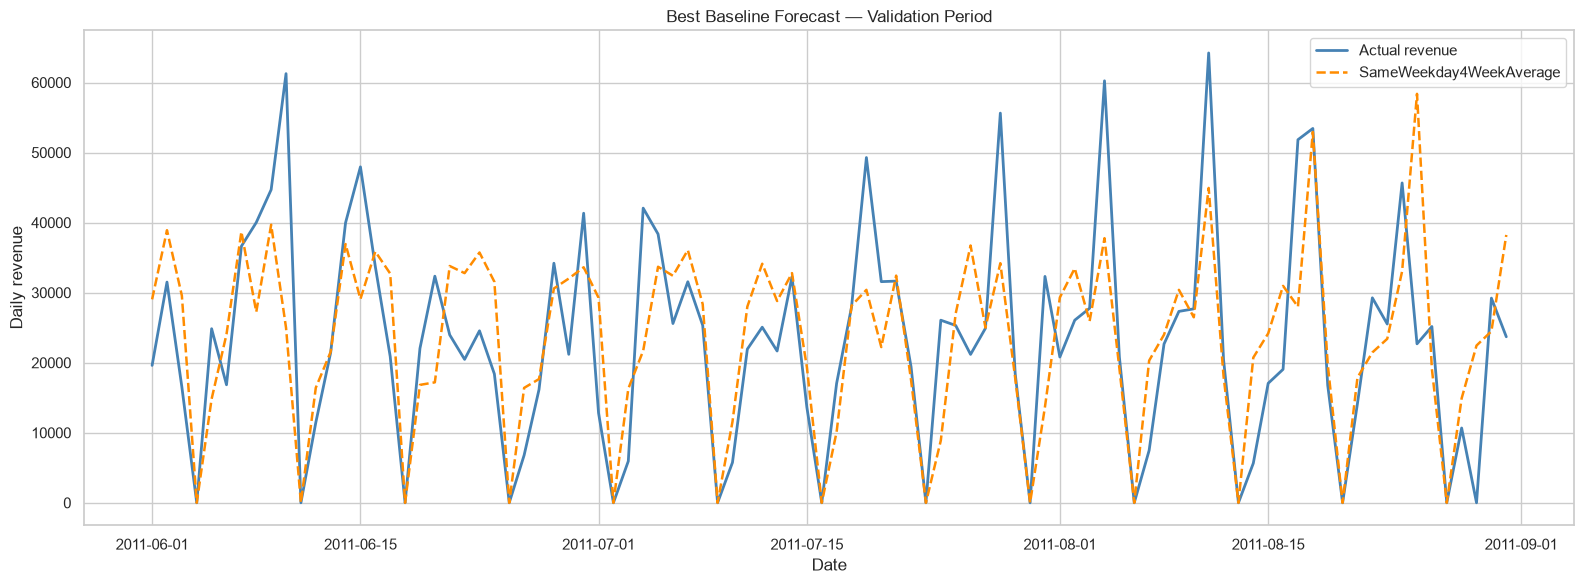

In [ ]:
plt.figure(figsize=(16, 6))

plt.plot(
    validation_baseline_df[
        "SalesDate"
    ],
    validation_baseline_df[
        "Revenue"
    ],
    label="Actual revenue",
    color="steelblue",
    linewidth=2
)

plt.plot(
    validation_baseline_df[
        "SalesDate"
    ],
    validation_baseline_df[
        best_baseline_name
    ],
    label=best_baseline_name,
    color="darkorange",
    linestyle="--",
    linewidth=1.8
)

plt.title(
    "Best Baseline Forecast — Validation Period"
)

plt.xlabel("Date")
plt.ylabel("Daily revenue")
plt.legend()
plt.tight_layout()
plt.savefig(
    segmentation_figure_dir / "Best_baseline_forecast.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

In [33]:
def create_forecast_features(
    daily_data
):
    feature_df = (
        daily_data
        .sort_values("SalesDate")
        .reset_index(drop=True)
        .copy()
    )

    date_values = feature_df["SalesDate"]

    # Calendar features known in advance
    feature_df["DayOfWeek"] = (
        date_values.dt.dayofweek
    )

    feature_df["DayOfMonth"] = (
        date_values.dt.day
    )

    feature_df["DayOfYear"] = (
        date_values.dt.dayofyear
    )

    feature_df["WeekOfYear"] = (
        date_values.dt.isocalendar()
        .week
        .astype(int)
    )

    feature_df["Month"] = (
        date_values.dt.month
    )

    feature_df["Quarter"] = (
        date_values.dt.quarter
    )

    feature_df["IsSaturday"] = (
        date_values.dt.dayofweek.eq(5)
        .astype(int)
    )

    feature_df["IsSunday"] = (
        date_values.dt.dayofweek.eq(6)
        .astype(int)
    )

    feature_df["TimeIndex"] = np.arange(
        len(feature_df)
    )

    # Cyclical calendar features
    feature_df["DayOfWeekSin"] = np.sin(
        2 * np.pi
        * feature_df["DayOfWeek"]
        / 7
    )

    feature_df["DayOfWeekCos"] = np.cos(
        2 * np.pi
        * feature_df["DayOfWeek"]
        / 7
    )

    feature_df["MonthSin"] = np.sin(
        2 * np.pi
        * feature_df["Month"]
        / 12
    )

    feature_df["MonthCos"] = np.cos(
        2 * np.pi
        * feature_df["Month"]
        / 12
    )

    # Historical revenue lags
    for lag in [1, 2, 3, 7, 14, 21, 28]:
        feature_df[
            f"RevenueLag{lag}"
        ] = feature_df[
            "Revenue"
        ].shift(lag)

    # Shift first so the current target is excluded
    historical_revenue = (
        feature_df["Revenue"]
        .shift(1)
    )

    for window in [7, 14, 28, 56]:

        feature_df[
            f"RevenueRollingMean{window}"
        ] = (
            historical_revenue
            .rolling(window)
            .mean()
        )

        feature_df[
            f"RevenueRollingStd{window}"
        ] = (
            historical_revenue
            .rolling(window)
            .std()
        )

    # Average revenue for the same weekday
    feature_df[
        "SameWeekday4WeekAverage"
    ] = pd.concat(
        [
            feature_df[
                "Revenue"
            ].shift(lag)
            for lag in [7, 14, 21, 28]
        ],
        axis=1
    ).mean(axis=1)

    # Smoothed recent history
    feature_df[
        "RevenueEWMA7"
    ] = (
        historical_revenue
        .ewm(
            span=7,
            adjust=False
        )
        .mean()
    )

    feature_df[
        "RevenueEWMA28"
    ] = (
        historical_revenue
        .ewm(
            span=28,
            adjust=False
        )
        .mean()
    )

    # Log target reduces the influence of extreme sales days
    feature_df[
        "LogRevenueTarget"
    ] = np.log1p(
        feature_df["Revenue"]
    )

    return feature_df

In [34]:
forecast_feature_df = (
    create_forecast_features(
        daily_sales
    )
)

Define the model features

In [35]:
forecast_feature_columns = [
    "DayOfWeek",
    "DayOfMonth",
    "DayOfYear",
    "WeekOfYear",
    "Month",
    "Quarter",
    "IsSaturday",
    "IsSunday",
    "TimeIndex",
    "DayOfWeekSin",
    "DayOfWeekCos",
    "MonthSin",
    "MonthCos",
    "RevenueLag1",
    "RevenueLag2",
    "RevenueLag3",
    "RevenueLag7",
    "RevenueLag14",
    "RevenueLag21",
    "RevenueLag28",
    "RevenueRollingMean7",
    "RevenueRollingStd7",
    "RevenueRollingMean14",
    "RevenueRollingStd14",
    "RevenueRollingMean28",
    "RevenueRollingStd28",
    "RevenueRollingMean56",
    "RevenueRollingStd56",
    "SameWeekday4WeekAverage",
    "RevenueEWMA7",
    "RevenueEWMA28"
]

forecast_target_column = (
    "LogRevenueTarget"
)

In [36]:
forecast_model_df = (
    forecast_feature_df
    .dropna(
        subset=(
            forecast_feature_columns
            + [forecast_target_column]
        )
    )
    .reset_index(drop=True)
)

print(
    "Original daily rows:",
    len(daily_sales)
)

print(
    "Model-ready rows:",
    len(forecast_model_df)
)

print(
    "Features:",
    len(forecast_feature_columns)
)

Original daily rows: 730
Model-ready rows: 674
Features: 31


In [37]:
forecast_train_model_df = (
    forecast_model_df.loc[
        forecast_model_df[
            "SalesDate"
        ] < forecast_validation_start
    ]
    .copy()
)

forecast_validation_model_df = (
    forecast_model_df.loc[
        forecast_model_df[
            "SalesDate"
        ].between(
            forecast_validation_start,
            forecast_test_start,
            inclusive="left"
        )
    ]
    .copy()
)

forecast_test_model_df = (
    forecast_model_df.loc[
        forecast_model_df[
            "SalesDate"
        ] >= forecast_test_start
    ]
    .copy()
)

In [38]:
X_forecast_train = (
    forecast_train_model_df[
        forecast_feature_columns
    ]
)

y_forecast_train = (
    forecast_train_model_df[
        forecast_target_column
    ]
)

X_forecast_validation = (
    forecast_validation_model_df[
        forecast_feature_columns
    ]
)

y_forecast_validation = (
    forecast_validation_model_df[
        forecast_target_column
    ]
)

X_forecast_test = (
    forecast_test_model_df[
        forecast_feature_columns
    ]
)

y_forecast_test = (
    forecast_test_model_df[
        forecast_target_column
    ]
)

In [39]:
assert "Revenue" not in (
    forecast_feature_columns
)

assert "LogRevenueTarget" not in (
    forecast_feature_columns
)

assert X_forecast_train.isna().sum().sum() == 0
assert X_forecast_validation.isna().sum().sum() == 0
assert X_forecast_test.isna().sum().sum() == 0

assert (
    forecast_train_model_df[
        "SalesDate"
    ].max()
    <
    forecast_validation_model_df[
        "SalesDate"
    ].min()
)

assert (
    forecast_validation_model_df[
        "SalesDate"
    ].max()
    <
    forecast_test_model_df[
        "SalesDate"
    ].min()
)

print("Forecast features validated.")

Forecast features validated.


In [40]:
feature_split_summary = pd.DataFrame({
    "Dataset": [
        "Train",
        "Validation",
        "Test"
    ],
    "Rows": [
        len(forecast_train_model_df),
        len(forecast_validation_model_df),
        len(forecast_test_model_df)
    ],
    "Start": [
        forecast_train_model_df[
            "SalesDate"
        ].min(),
        forecast_validation_model_df[
            "SalesDate"
        ].min(),
        forecast_test_model_df[
            "SalesDate"
        ].min()
    ],
    "End": [
        forecast_train_model_df[
            "SalesDate"
        ].max(),
        forecast_validation_model_df[
            "SalesDate"
        ].max(),
        forecast_test_model_df[
            "SalesDate"
        ].max()
    ]
})

feature_split_summary

,Dataset,Rows,Start,End
0,Train,491,2010-01-26,2011-05-31
1,Validation,92,2011-06-01,2011-08-31
2,Test,91,2011-09-01,2011-11-30


XGBoost pipeline and validation tuning

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import ParameterGrid

from xgboost import XGBRegressor

In [42]:
def calculate_forecast_metrics(
    actual,
    predicted
):
    actual_array = np.asarray(
        actual,
        dtype=float
    )

    predicted_array = np.asarray(
        predicted,
        dtype=float
    )

    valid_mask = (
        np.isfinite(actual_array)
        & np.isfinite(predicted_array)
    )

    actual_array = actual_array[
        valid_mask
    ]

    predicted_array = predicted_array[
        valid_mask
    ]

    error = (
        predicted_array
        - actual_array
    )

    absolute_error = np.abs(error)

    mae = np.mean(absolute_error)

    rmse = np.sqrt(
        np.mean(error ** 2)
    )

    wape = (
        absolute_error.sum()
        / np.abs(actual_array).sum()
        * 100
    )

    bias_percent = (
        error.sum()
        / actual_array.sum()
        * 100
    )

    smape_denominator = (
        np.abs(actual_array)
        + np.abs(predicted_array)
    )

    valid_smape = (
        smape_denominator > 0
    )

    smape = (
        np.mean(
            2
            * absolute_error[valid_smape]
            / smape_denominator[valid_smape]
        )
        * 100
    )

    return {
        "Observations": len(actual_array),
        "MAE": mae,
        "RMSE": rmse,
        "WAPEPercent": wape,
        "SMAPEPercent": smape,
        "BiasPercent": bias_percent
    }

In [43]:
xgb_parameter_grid = {
    "n_estimators": [
        200,
        400
    ],
    "max_depth": [
        2,
        3,
        4
    ],
    "learning_rate": [
        0.03,
        0.05
    ]
}

xgb_candidates = list(
    ParameterGrid(
        xgb_parameter_grid
    )
)

print(
    "Candidate models:",
    len(xgb_candidates)
)

Candidate models: 12


In [44]:
xgb_validation_records = []
xgb_candidate_models = {}

actual_validation_revenue = (
    forecast_validation_model_df[
        "Revenue"
    ].to_numpy()
)

for candidate_number, parameters in enumerate(
    xgb_candidates,
    start=1
):
    candidate_name = (
        f"XGB_{candidate_number:02d}"
    )

    candidate_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "model",
                XGBRegressor(
                    objective="reg:squarederror",
                    random_state=42,
                    tree_method="hist",
                    n_jobs=-1,
                    min_child_weight=5,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=5.0,
                    **parameters
                )
            )
        ]
    )

    candidate_pipeline.fit(
        X_forecast_train,
        y_forecast_train
    )

    validation_log_prediction = (
        candidate_pipeline.predict(
            X_forecast_validation
        )
    )

    validation_revenue_prediction = (
        np.expm1(
            validation_log_prediction
        )
    )

    validation_revenue_prediction = (
        np.clip(
            validation_revenue_prediction,
            a_min=0,
            a_max=None
        )
    )

    candidate_metrics = (
        calculate_forecast_metrics(
            actual_validation_revenue,
            validation_revenue_prediction
        )
    )

    xgb_validation_records.append({
        "Candidate": candidate_name,
        **parameters,
        **candidate_metrics
    })

    xgb_candidate_models[
        candidate_name
    ] = candidate_pipeline

Rank candidates using validation WAPE

In [45]:
xgb_tuning_results = (
    pd.DataFrame(
        xgb_validation_records
    )
    .sort_values(
        [
            "WAPEPercent",
            "RMSE"
        ]
    )
    .reset_index(drop=True)
)

xgb_tuning_results.round(3)

,Candidate,learning_rate,max_depth,n_estimators,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent
0,XGB_01,0.03,2,200,92,10435.995,15085.887,45.137,69.795,-38.901
1,XGB_05,0.03,4,200,92,10469.208,14741.719,45.281,80.255,-34.833
2,XGB_02,0.03,2,400,92,10507.920,15329.776,45.448,69.646,-34.246
3,XGB_04,0.03,3,400,92,10620.941,15614.361,45.937,81.501,-39.212
4,XGB_10,0.05,3,400,92,10904.064,16032.723,47.162,79.594,-37.648
5,XGB_03,0.03,3,200,92,10921.821,15864.623,47.239,81.513,-45.779
6,XGB_09,0.05,3,200,92,10962.614,16300.946,47.415,83.784,-44.365
7,XGB_07,0.05,2,200,92,10979.805,15757.123,47.489,65.536,-40.202
8,XGB_06,0.03,4,400,92,11011.635,15426.900,47.627,82.088,-33.768
9,XGB_11,0.05,4,200,92,11089.459,15850.286,47.964,86.639,-38.262


Select the best candidate:

In [46]:
best_xgb_candidate = (
    xgb_tuning_results.loc[
        0,
        "Candidate"
    ]
)

best_xgb_pipeline = (
    xgb_candidate_models[
        best_xgb_candidate
    ]
)

best_xgb_parameters = (
    xgb_tuning_results.loc[
        0,
        [
            "n_estimators",
            "max_depth",
            "learning_rate"
        ]
    ]
    .to_dict()
)

print(
    "Selected XGBoost:",
    best_xgb_candidate
)

print(
    "Parameters:",
    best_xgb_parameters
)

Selected XGBoost: XGB_01
Parameters: {'n_estimators': 200.0, 'max_depth': 2.0, 'learning_rate': 0.03}


Generate the selected validation forecast

In [47]:
best_xgb_validation_log = (
    best_xgb_pipeline.predict(
        X_forecast_validation
    )
)

best_xgb_validation_prediction = (
    np.clip(
        np.expm1(
            best_xgb_validation_log
        ),
        a_min=0,
        a_max=None
    )
)

best_xgb_validation_metrics = (
    calculate_forecast_metrics(
        actual_validation_revenue,
        best_xgb_validation_prediction
    )
)

pd.Series(
    best_xgb_validation_metrics,
    name="Best XGBoost"
).round(3)

Observations       92.000
MAE             10435.995
RMSE            15085.887
WAPEPercent        45.137
SMAPEPercent       69.795
BiasPercent       -38.901
Name: Best XGBoost, dtype: float64

Compare XGBoost against the baseline

In [48]:
validation_model_comparison = pd.DataFrame(
    [
        {
            "Model":
                best_baseline_name,

            **baseline_validation_results
            .loc[best_baseline_name]
            .to_dict()
        },
        {
            "Model":
                "XGBoost",

            **best_xgb_validation_metrics
        }
    ]
).set_index("Model")

validation_model_comparison = (
    validation_model_comparison
    .sort_values("WAPEPercent")
)

validation_model_comparison.round(3)

,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent
Model,,,,,,
SameWeekday4WeekAverage,92.0,7774.359,10963.697,33.625,36.561,1.281
XGBoost,92.0,10435.995,15085.887,45.137,69.795,-38.901


Calculate improvement:

In [49]:
baseline_wape = (
    baseline_validation_results.loc[
        best_baseline_name,
        "WAPEPercent"
    ]
)

xgb_wape = (
    best_xgb_validation_metrics[
        "WAPEPercent"
    ]
)

xgb_improvement_percent = (
    (
        baseline_wape
        - xgb_wape
    )
    / baseline_wape
    * 100
)

print(
    "XGBoost improvement over baseline:",
    round(
        xgb_improvement_percent,
        2
    ),
    "%"
)

XGBoost improvement over baseline: -34.24 %


Plot the validation comparison

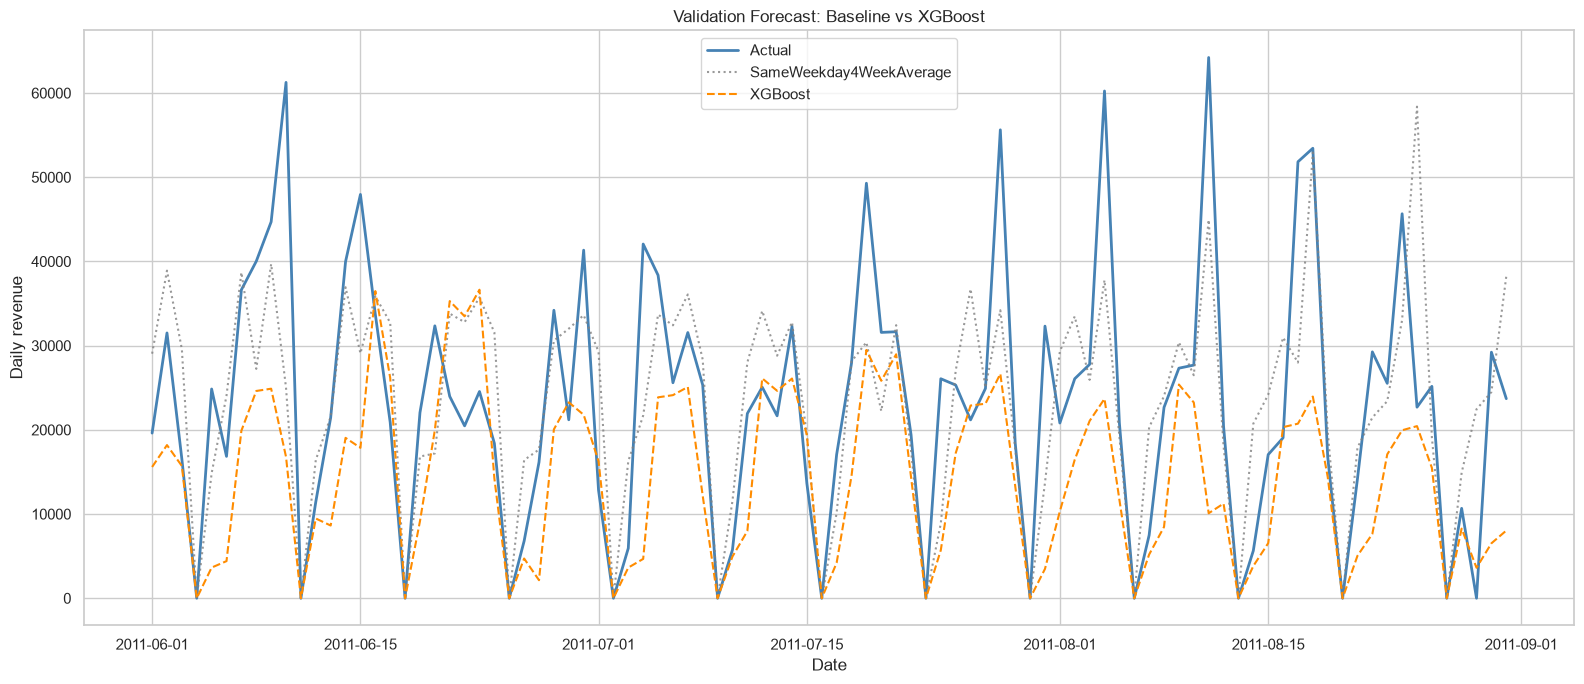

In [50]:
validation_forecast_plot = (
    forecast_validation_model_df[
        [
            "SalesDate",
            "Revenue"
        ]
    ]
    .copy()
)

validation_forecast_plot[
    "XGBoost"
] = best_xgb_validation_prediction

baseline_lookup = (
    forecast_baseline_df
    .set_index("SalesDate")[
        best_baseline_name
    ]
)

validation_forecast_plot[
    "Baseline"
] = (
    validation_forecast_plot[
        "SalesDate"
    ]
    .map(baseline_lookup)
)

plt.figure(figsize=(16, 7))

plt.plot(
    validation_forecast_plot[
        "SalesDate"
    ],
    validation_forecast_plot[
        "Revenue"
    ],
    label="Actual",
    color="steelblue",
    linewidth=2
)

plt.plot(
    validation_forecast_plot[
        "SalesDate"
    ],
    validation_forecast_plot[
        "Baseline"
    ],
    label=best_baseline_name,
    color="grey",
    linestyle=":",
    alpha=0.8
)

plt.plot(
    validation_forecast_plot[
        "SalesDate"
    ],
    validation_forecast_plot[
        "XGBoost"
    ],
    label="XGBoost",
    color="darkorange",
    linestyle="--"
)

plt.title(
    "Validation Forecast: Baseline vs XGBoost"
)

plt.xlabel("Date")
plt.ylabel("Daily revenue")
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
y_forecast_train_revenue = (
    forecast_train_model_df[
        "Revenue"
    ]
)

actual_validation_revenue = (
    forecast_validation_model_df[
        "Revenue"
    ].to_numpy()
)

In [52]:
direct_xgb_records = []
direct_xgb_models = {}

for candidate_number, parameters in enumerate(
    xgb_candidates,
    start=1
):
    candidate_name = (
        f"DirectXGB_{candidate_number:02d}"
    )

    candidate_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "model",
                XGBRegressor(
                    objective="reg:squarederror",
                    random_state=42,
                    tree_method="hist",
                    n_jobs=-1,
                    min_child_weight=5,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=5.0,
                    **parameters
                )
            )
        ]
    )

    candidate_pipeline.fit(
        X_forecast_train,
        y_forecast_train_revenue
    )

    validation_prediction = (
        candidate_pipeline.predict(
            X_forecast_validation
        )
    )

    validation_prediction = np.clip(
        validation_prediction,
        a_min=0,
        a_max=None
    )

    candidate_metrics = (
        calculate_forecast_metrics(
            actual_validation_revenue,
            validation_prediction
        )
    )

    direct_xgb_records.append({
        "Candidate": candidate_name,
        **parameters,
        **candidate_metrics
    })

    direct_xgb_models[
        candidate_name
    ] = candidate_pipeline

In [53]:
direct_xgb_tuning_results = (
    pd.DataFrame(
        direct_xgb_records
    )
    .sort_values(
        [
            "WAPEPercent",
            "RMSE"
        ]
    )
    .reset_index(drop=True)
)

direct_xgb_tuning_results.round(3)

,Candidate,learning_rate,max_depth,n_estimators,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent
0,DirectXGB_07,0.05,2,200,92,7886.740,11452.747,34.111,47.892,-9.560
1,DirectXGB_01,0.03,2,200,92,7923.091,11272.844,34.269,59.582,-7.493
2,DirectXGB_08,0.05,2,400,92,8003.028,11712.468,34.614,48.170,-9.697
3,DirectXGB_02,0.03,2,400,92,8030.634,11682.097,34.734,50.023,-9.354
4,DirectXGB_03,0.03,3,200,92,8050.543,11300.180,34.820,59.446,-6.222
5,DirectXGB_09,0.05,3,200,92,8185.819,11706.002,35.405,57.221,-7.772
6,DirectXGB_04,0.03,3,400,92,8191.704,11775.701,35.430,58.643,-8.199
7,DirectXGB_05,0.03,4,200,92,8195.459,11441.072,35.447,60.884,-7.525
8,DirectXGB_11,0.05,4,200,92,8456.881,11930.516,36.577,61.914,-8.651
9,DirectXGB_10,0.05,3,400,92,8465.541,11872.947,36.615,56.282,-5.557


In [54]:
best_direct_xgb_candidate = (
    direct_xgb_tuning_results.loc[
        0,
        "Candidate"
    ]
)

best_direct_xgb_pipeline = (
    direct_xgb_models[
        best_direct_xgb_candidate
    ]
)

best_direct_xgb_prediction = (
    best_direct_xgb_pipeline.predict(
        X_forecast_validation
    )
)

best_direct_xgb_prediction = np.clip(
    best_direct_xgb_prediction,
    a_min=0,
    a_max=None
)

best_direct_xgb_metrics = (
    calculate_forecast_metrics(
        actual_validation_revenue,
        best_direct_xgb_prediction
    )
)

print(
    "Selected model:",
    best_direct_xgb_candidate
)

pd.Series(
    best_direct_xgb_metrics,
    name="Direct-revenue XGBoost"
).round(3)

Selected model: DirectXGB_07


Observations       92.000
MAE              7886.740
RMSE            11452.747
WAPEPercent        34.111
SMAPEPercent       47.892
BiasPercent        -9.560
Name: Direct-revenue XGBoost, dtype: float64

In [55]:
revised_validation_comparison = pd.DataFrame(
    [
        {
            "Model":
                best_baseline_name,

            **baseline_validation_results
            .loc[best_baseline_name]
            .to_dict()
        },
        {
            "Model":
                "Log-target XGBoost",

            **best_xgb_validation_metrics
        },
        {
            "Model":
                "Direct-revenue XGBoost",

            **best_direct_xgb_metrics
        }
    ]
).set_index("Model")

revised_validation_comparison = (
    revised_validation_comparison
    .sort_values("WAPEPercent")
)

revised_validation_comparison.round(3)

,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent
Model,,,,,,
SameWeekday4WeekAverage,92.0,7774.359,10963.697,33.625,36.561,1.281
Direct-revenue XGBoost,92.0,7886.740,11452.747,34.111,47.892,-9.560
Log-target XGBoost,92.0,10435.995,15085.887,45.137,69.795,-38.901


In [56]:
direct_xgb_improvement = (
    (
        baseline_wape
        - best_direct_xgb_metrics[
            "WAPEPercent"
        ]
    )
    / baseline_wape
    * 100
)

print(
    "Direct XGBoost improvement "
    "over baseline:",
    round(
        direct_xgb_improvement,
        2
    ),
    "%"
)

Direct XGBoost improvement over baseline: -1.45 %


In [57]:
baseline_prediction_lookup = (
    forecast_baseline_df
    .set_index("SalesDate")[
        best_baseline_name
    ]
)

train_baseline_prediction = (
    forecast_train_model_df[
        "SalesDate"
    ]
    .map(baseline_prediction_lookup)
)

validation_baseline_prediction = (
    forecast_validation_model_df[
        "SalesDate"
    ]
    .map(baseline_prediction_lookup)
)

assert train_baseline_prediction.notna().all()
assert validation_baseline_prediction.notna().all()

A positive residual means the baseline under-forecasted; a negative residual means it over-forecasted.

In [58]:
train_residual_target = (
    forecast_train_model_df[
        "Revenue"
    ].to_numpy()
    -
    train_baseline_prediction.to_numpy()
)

pd.Series(
    train_residual_target
).describe()

count      491.000000
mean       122.000538
std      13069.152395
min     -57092.417500
25%      -5043.486250
50%          0.000000
75%       4779.091250
max      72095.810000
dtype: float64

In [59]:
hybrid_xgb_records = []
hybrid_xgb_models = {}

for candidate_number, parameters in enumerate(
    xgb_candidates,
    start=1
):
    candidate_name = (
        f"HybridXGB_{candidate_number:02d}"
    )

    residual_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "model",
                XGBRegressor(
                    objective="reg:squarederror",
                    random_state=42,
                    tree_method="hist",
                    n_jobs=-1,
                    min_child_weight=5,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=5.0,
                    **parameters
                )
            )
        ]
    )

    residual_pipeline.fit(
        X_forecast_train,
        train_residual_target
    )

    predicted_residual = (
        residual_pipeline.predict(
            X_forecast_validation
        )
    )

    hybrid_prediction = (
        validation_baseline_prediction
        .to_numpy()
        + predicted_residual
    )

    hybrid_prediction = np.clip(
        hybrid_prediction,
        a_min=0,
        a_max=None
    )

    candidate_metrics = (
        calculate_forecast_metrics(
            actual_validation_revenue,
            hybrid_prediction
        )
    )

    hybrid_xgb_records.append({
        "Candidate": candidate_name,
        **parameters,
        **candidate_metrics
    })

    hybrid_xgb_models[
        candidate_name
    ] = residual_pipeline

In [60]:
hybrid_xgb_tuning_results = (
    pd.DataFrame(
        hybrid_xgb_records
    )
    .sort_values(
        [
            "WAPEPercent",
            "RMSE"
        ]
    )
    .reset_index(drop=True)
)

hybrid_xgb_tuning_results.round(3)

,Candidate,learning_rate,max_depth,n_estimators,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent
0,HybridXGB_01,0.03,2,200,92,7899.922,10743.359,34.168,53.019,0.161
1,HybridXGB_03,0.03,3,200,92,7984.755,10975.314,34.535,57.758,-0.767
2,HybridXGB_07,0.05,2,200,92,8008.650,10945.111,34.639,49.624,-0.240
3,HybridXGB_02,0.03,2,400,92,8022.609,11031.036,34.699,47.842,-1.359
4,HybridXGB_05,0.03,4,200,92,8057.148,11097.410,34.848,56.075,-0.868
5,HybridXGB_09,0.05,3,200,92,8074.032,11176.265,34.921,51.347,-1.611
6,HybridXGB_04,0.03,3,400,92,8124.104,11293.822,35.138,54.714,-1.467
7,HybridXGB_08,0.05,2,400,92,8217.637,11346.116,35.543,48.000,-1.579
8,HybridXGB_11,0.05,4,200,92,8336.132,11347.740,36.055,57.034,-0.645
9,HybridXGB_06,0.03,4,400,92,8368.006,11367.319,36.193,56.799,-0.783


In [61]:
best_hybrid_candidate = (
    hybrid_xgb_tuning_results.loc[
        0,
        "Candidate"
    ]
)

best_hybrid_pipeline = (
    hybrid_xgb_models[
        best_hybrid_candidate
    ]
)

best_hybrid_parameters = (
    hybrid_xgb_tuning_results.loc[
        0,
        [
            "n_estimators",
            "max_depth",
            "learning_rate"
        ]
    ]
    .to_dict()
)

print(
    "Selected hybrid candidate:",
    best_hybrid_candidate
)

print(
    "Parameters:",
    best_hybrid_parameters
)

Selected hybrid candidate: HybridXGB_01
Parameters: {'n_estimators': 200.0, 'max_depth': 2.0, 'learning_rate': 0.03}


In [62]:
best_validation_residual = (
    best_hybrid_pipeline.predict(
        X_forecast_validation
    )
)

best_hybrid_validation_prediction = (
    validation_baseline_prediction
    .to_numpy()
    + best_validation_residual
)

best_hybrid_validation_prediction = (
    np.clip(
        best_hybrid_validation_prediction,
        a_min=0,
        a_max=None
    )
)

best_hybrid_metrics = (
    calculate_forecast_metrics(
        actual_validation_revenue,
        best_hybrid_validation_prediction
    )
)

pd.Series(
    best_hybrid_metrics,
    name="Hybrid XGBoost"
).round(3)

Observations       92.000
MAE              7899.922
RMSE            10743.359
WAPEPercent        34.168
SMAPEPercent       53.019
BiasPercent         0.161
Name: Hybrid XGBoost, dtype: float64

Final validation comparison

In [63]:
final_validation_comparison = pd.DataFrame(
    [
        {
            "Model":
                best_baseline_name,

            **baseline_validation_results
            .loc[best_baseline_name]
            .to_dict()
        },
        {
            "Model":
                "Log-target XGBoost",

            **best_xgb_validation_metrics
        },
        {
            "Model":
                "Direct-revenue XGBoost",

            **best_direct_xgb_metrics
        },
        {
            "Model":
                "Baseline + XGBoost residual",

            **best_hybrid_metrics
        }
    ]
).set_index("Model")

final_validation_comparison = (
    final_validation_comparison
    .sort_values("WAPEPercent")
)

final_validation_comparison.round(3)

,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent
Model,,,,,,
SameWeekday4WeekAverage,92.0,7774.359,10963.697,33.625,36.561,1.281
Direct-revenue XGBoost,92.0,7886.740,11452.747,34.111,47.892,-9.560
Baseline + XGBoost residual,92.0,7899.922,10743.359,34.168,53.019,0.161
Log-target XGBoost,92.0,10435.995,15085.887,45.137,69.795,-38.901


In [64]:
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


def calculate_forecast_metrics(
    actual,
    predicted
):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    predicted = np.clip(
        predicted,
        a_min=0,
        a_max=None
    )

    error = predicted - actual

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    wape = (
        np.abs(error).sum()
        / np.abs(actual).sum()
        * 100
    )

    smape_denominator = (
        np.abs(actual)
        + np.abs(predicted)
    )

    valid_smape = smape_denominator > 0

    smape = (
        np.mean(
            2
            * np.abs(error[valid_smape])
            / smape_denominator[valid_smape]
        )
        * 100
    )

    bias = (
        error.sum()
        / np.abs(actual).sum()
        * 100
    )

    return {
        "Observations": len(actual),
        "MAE": mae,
        "RMSE": rmse,
        "WAPEPercent": wape,
        "SMAPEPercent": smape,
        "BiasPercent": bias
    }

In [65]:
y_forecast_train_raw = np.expm1(
    np.asarray(
        y_forecast_train,
        dtype=float
    )
)

y_forecast_validation_raw = np.expm1(
    np.asarray(
        y_forecast_validation,
        dtype=float
    )
)

print(
    "Training observations:",
    len(y_forecast_train_raw)
)

print(
    "Validation observations:",
    len(y_forecast_validation_raw)
)

Training observations: 491
Validation observations: 92


In [66]:
xgb_parameter_candidates = [
    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_child_weight": 5
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_child_weight": 10
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_child_weight": 10
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.02,
        "max_depth": 3,
        "min_child_weight": 10
    },
    {
        "n_estimators": 400,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 15
    },
    {
        "n_estimators": 600,
        "learning_rate": 0.02,
        "max_depth": 2,
        "min_child_weight": 15
    }
]

In [67]:
xgb_validation_results = []
xgb_candidate_models = []

for candidate_number, parameters in enumerate(
    xgb_parameter_candidates,
    start=1
):
    candidate_model = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="mae",
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.10,
        reg_lambda=2.00,
        random_state=42,
        tree_method="hist",
        n_jobs=-1,
        **parameters
    )

    candidate_model.fit(
        X_forecast_train,
        y_forecast_train_raw,
        verbose=False
    )

    validation_prediction = np.clip(
        candidate_model.predict(
            X_forecast_validation
        ),
        a_min=0,
        a_max=None
    )

    candidate_metrics = (
        calculate_forecast_metrics(
            y_forecast_validation_raw,
            validation_prediction
        )
    )

    xgb_validation_results.append({
        "Candidate": candidate_number,
        **parameters,
        **candidate_metrics
    })

    xgb_candidate_models.append(
        candidate_model
    )

In [68]:
xgb_validation_results_df = pd.DataFrame(
    xgb_validation_results
)

best_candidate_index = (
    xgb_validation_results_df[
        "WAPEPercent"
    ].idxmin()
)

best_xgb_validation_model = (
    xgb_candidate_models[
        best_candidate_index
    ]
)

best_xgb_parameters = (
    xgb_parameter_candidates[
        best_candidate_index
    ]
)

xgb_validation_results_df.sort_values(
    [
        "WAPEPercent",
        "MAE"
    ]
).round(3)

,Candidate,n_estimators,learning_rate,max_depth,min_child_weight,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent
0,1,300,0.03,2,5,92,7978.098,11376.619,34.507,56.482,-7.556
5,6,600,0.02,2,15,92,8016.010,11598.071,34.670,48.256,-9.030
1,2,500,0.03,2,10,92,8018.375,11602.052,34.681,48.081,-8.028
3,4,500,0.02,3,10,92,8142.113,11689.911,35.216,55.513,-6.643
2,3,300,0.05,2,10,92,8175.053,11646.241,35.358,52.209,-7.126
4,5,400,0.03,3,15,92,8333.715,11890.647,36.045,57.820,-9.539


In [69]:
validation_baseline_prediction = (
    forecast_validation_model_df
    .loc[
        X_forecast_validation.index,
        "SameWeekday4WeekAverage"
    ]
    .to_numpy()
)

baseline_validation_metrics = (
    calculate_forecast_metrics(
        y_forecast_validation_raw,
        validation_baseline_prediction
    )
)

best_xgb_validation_metrics = (
    xgb_validation_results_df
    .loc[best_candidate_index]
    .to_dict()
)

validation_model_comparison = pd.DataFrame([
    {
        "Model": "SameWeekday4WeekAverage",
        **baseline_validation_metrics
    },
    {
        "Model": "Tuned XGBoost Raw Target",
        **{
            metric: best_xgb_validation_metrics[metric]
            for metric in [
                "Observations",
                "MAE",
                "RMSE",
                "WAPEPercent",
                "SMAPEPercent",
                "BiasPercent"
            ]
        }
    }
]).set_index("Model")

validation_model_comparison.round(3)

,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent
Model,,,,,,
SameWeekday4WeekAverage,92.0,7774.359,10963.697,33.625,36.561,1.281
Tuned XGBoost Raw Target,92.0,7978.098,11376.619,34.507,56.482,-7.556


In [70]:
hybrid_improvement_percent = (
    (
        baseline_wape
        - best_hybrid_metrics[
            "WAPEPercent"
        ]
    )
    / baseline_wape
    * 100
)

print(
    "Hybrid improvement over baseline:",
    round(
        hybrid_improvement_percent,
        2
    ),
    "%"
)

selected_validation_model = (
    final_validation_comparison
    .index[0]
)

print(
    "Validation winner:",
    selected_validation_model
)

Hybrid improvement over baseline: -1.62 %
Validation winner: SameWeekday4WeekAverage


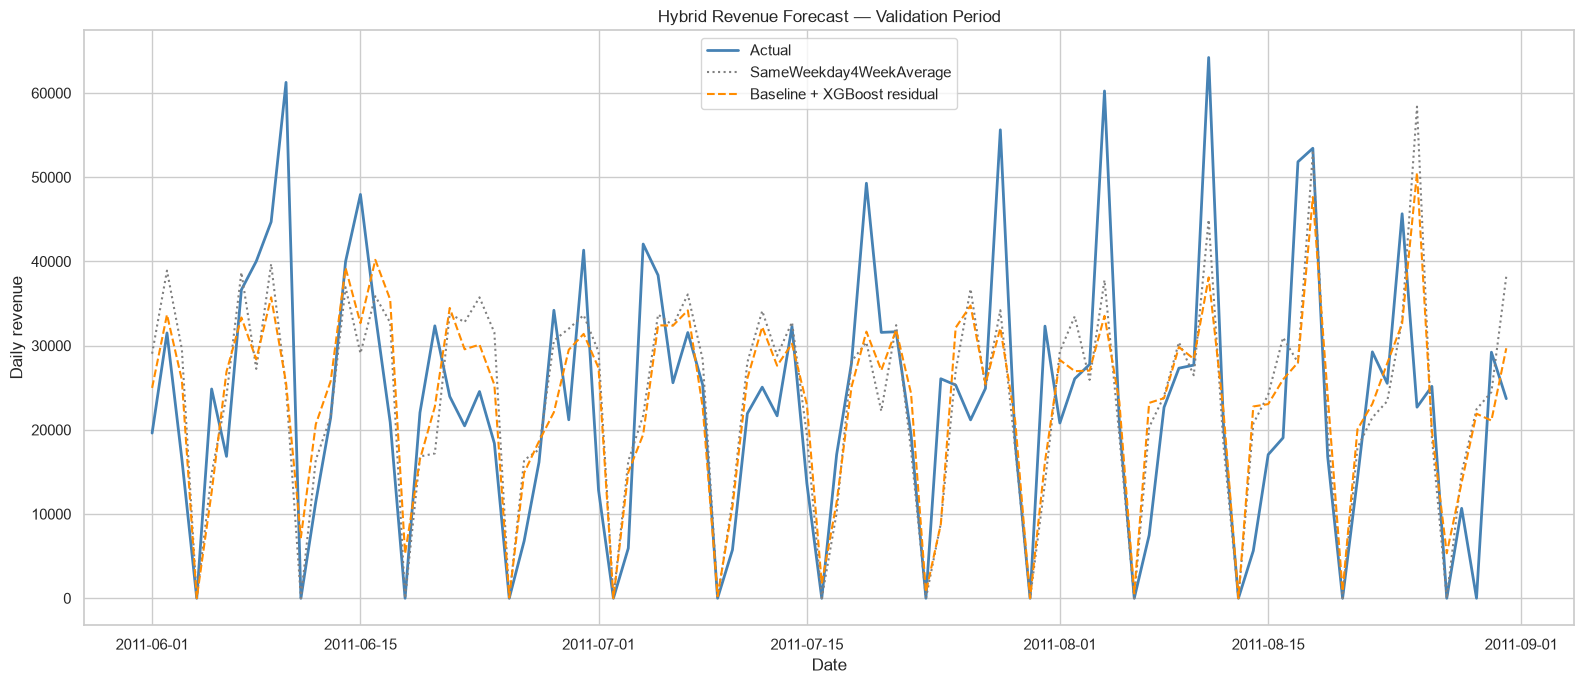

In [71]:
plt.figure(figsize=(16, 7))

plt.plot(
    forecast_validation_model_df[
        "SalesDate"
    ],
    actual_validation_revenue,
    label="Actual",
    color="steelblue",
    linewidth=2
)

plt.plot(
    forecast_validation_model_df[
        "SalesDate"
    ],
    validation_baseline_prediction,
    label=best_baseline_name,
    color="grey",
    linestyle=":"
)

plt.plot(
    forecast_validation_model_df[
        "SalesDate"
    ],
    best_hybrid_validation_prediction,
    label="Baseline + XGBoost residual",
    color="darkorange",
    linestyle="--"
)

plt.title(
    "Hybrid Revenue Forecast — Validation Period"
)

plt.xlabel("Date")
plt.ylabel("Daily revenue")
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
X_forecast_development = pd.concat(
    [
        X_forecast_train,
        X_forecast_validation
    ],
    axis=0
).sort_index()

y_forecast_development_raw = np.concatenate(
    [
        y_forecast_train_raw,
        y_forecast_validation_raw
    ]
)

print(
    "Development observations:",
    len(X_forecast_development)
)

print(
    "Development target observations:",
    len(y_forecast_development_raw)
)

Development observations: 583
Development target observations: 583


Prepare the test target

In [73]:
y_forecast_test_raw = np.expm1(
    np.asarray(
        y_forecast_test,
        dtype=float
    )
)

print(
    "Test observations:",
    len(y_forecast_test_raw)
)

Test observations: 91


In [74]:
final_xgb_forecast_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="mae",
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=2.00,
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
    **best_xgb_parameters
)

final_xgb_forecast_model.fit(
    X_forecast_development,
    y_forecast_development_raw,
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'mae'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [75]:
xgb_test_prediction = np.clip(
    final_xgb_forecast_model.predict(
        X_forecast_test
    ),
    a_min=0,
    a_max=None
)

baseline_test_prediction = (
    forecast_test_model_df
    .loc[
        X_forecast_test.index,
        "SameWeekday4WeekAverage"
    ]
    .to_numpy()
)

Compare final test performance

In [76]:
baseline_test_metrics = (
    calculate_forecast_metrics(
        y_forecast_test_raw,
        baseline_test_prediction
    )
)

xgb_test_metrics = (
    calculate_forecast_metrics(
        y_forecast_test_raw,
        xgb_test_prediction
    )
)

final_test_comparison = pd.DataFrame([
    {
        "Model": "SameWeekday4WeekAverage",
        **baseline_test_metrics
    },
    {
        "Model": "Tuned XGBoost Raw Target",
        **xgb_test_metrics
    }
]).set_index("Model")

final_test_comparison.round(3)

,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent
Model,,,,,,
SameWeekday4WeekAverage,91,12068.298,16978.475,31.138,33.967,-12.418
Tuned XGBoost Raw Target,91,9800.317,14121.721,25.287,51.345,-2.675


In [ ]:
baseline_test_wape = final_test_comparison.loc[
    "SameWeekday4WeekAverage",
    "WAPEPercent"
]

xgb_test_wape = final_test_comparison.loc[
    "Tuned XGBoost Raw Target",
    "WAPEPercent"
]

xgb_improvement_percent = (
    (
        baseline_test_wape
        - xgb_test_wape
    )
    / baseline_test_wape
    * 100
)

print(
    "XGBoost improvement over baseline:",
    round(xgb_improvement_percent, 2),
    "%"
)

XGBoost improvement over baseline: 18.79 %


In [78]:
VALIDATION_MONTHS = 3
TEST_MONTHS = 3

test_start_month = (
    last_complete_month
    - (TEST_MONTHS - 1)
)

validation_start_month = (
    test_start_month
    - VALIDATION_MONTHS
)

print(
    "Validation start:",
    validation_start_month
)

print(
    "Test start:",
    test_start_month
)

Validation start: 2011-06
Test start: 2011-09


In [79]:
preferred_date_columns = [
    "Date",
    "InvoiceDate",
    "ForecastDate",
    "TransactionDate"
]

date_candidates = [
    column
    for column in preferred_date_columns
    if column in forecast_test_model_df.columns
]

if not date_candidates:
    date_candidates = [
        column
        for column in forecast_test_model_df.columns
        if "date" in column.lower()
    ]

if not date_candidates:
    date_candidates = [
        column
        for column in forecast_test_model_df.columns
        if pd.api.types.is_datetime64_any_dtype(
            forecast_test_model_df[column]
        )
    ]

if not date_candidates:
    raise ValueError(
        "No date column found. Available columns: "
        f"{forecast_test_model_df.columns.tolist()}"
    )

forecast_date_column = date_candidates[0]

print(
    "Date column selected:",
    forecast_date_column
)

forecast_test_dates = pd.to_datetime(
    forecast_test_model_df.loc[
        X_forecast_test.index,
        forecast_date_column
    ],
    errors="raise"
)

print(
    "Forecast dates:",
    forecast_test_dates.min(),
    "to",
    forecast_test_dates.max()
)

Date column selected: SalesDate
Forecast dates: 2011-09-01 00:00:00 to 2011-11-30 00:00:00


In [80]:
import matplotlib.dates as mdates

forecast_test_dates = pd.to_datetime(
    forecast_test_model_df.loc[
        X_forecast_test.index,
        forecast_date_column
    ],
    errors="raise"
)

forecast_test_results = pd.DataFrame({
    "ForecastDate": (
        forecast_test_dates.to_numpy()
    ),
    "ActualRevenue": np.asarray(
        y_forecast_test_raw
    ).ravel(),
    "BaselinePrediction": np.asarray(
        baseline_test_prediction
    ).ravel(),
    "XGBoostPrediction": np.asarray(
        xgb_test_prediction
    ).ravel()
})

forecast_test_results = (
    forecast_test_results
    .set_index("ForecastDate")
    .sort_index()
)

forecast_test_results.head()

,ActualRevenue,BaselinePrediction,XGBoostPrediction
ForecastDate,,,
2011-09-01,36684.13,50147.3300,32624.363281
2011-09-02,39964.33,20800.5325,21173.263672
2011-09-03,0.00,0.0000,1544.584229
2011-09-04,16828.84,9501.7125,12189.321289
2011-09-05,36004.99,17245.6225,25711.976562


In [81]:
print(
    "Plot start:",
    forecast_test_results.index.min()
)

print(
    "Plot end:",
    forecast_test_results.index.max()
)

assert len(forecast_test_results) == 91

assert forecast_test_results.index.min() == (
    pd.Timestamp("2011-09-01")
)

assert forecast_test_results.index.max() == (
    pd.Timestamp("2011-11-30")
)

Plot start: 2011-09-01 00:00:00
Plot end: 2011-11-30 00:00:00


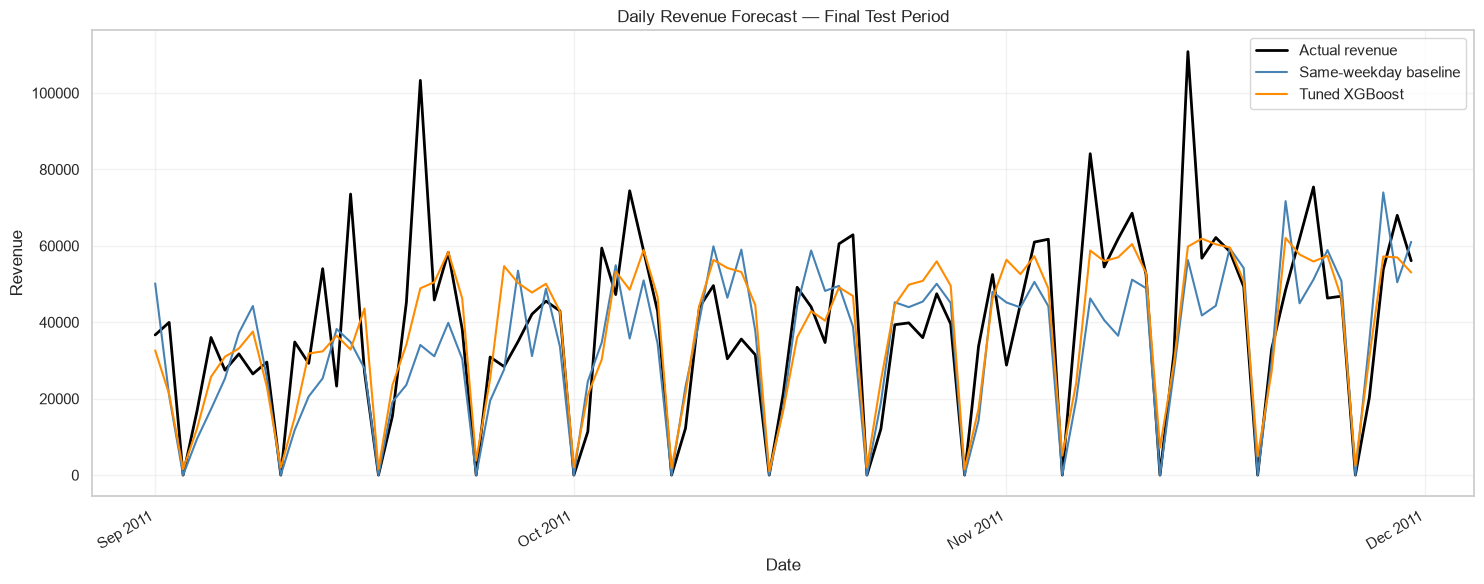

In [82]:
fig, ax = plt.subplots(
    figsize=(15, 6)
)

ax.plot(
    forecast_test_results.index,
    forecast_test_results[
        "ActualRevenue"
    ],
    label="Actual revenue",
    color="black",
    linewidth=2
)

ax.plot(
    forecast_test_results.index,
    forecast_test_results[
        "BaselinePrediction"
    ],
    label="Same-weekday baseline",
    color="steelblue",
    linewidth=1.5
)

ax.plot(
    forecast_test_results.index,
    forecast_test_results[
        "XGBoostPrediction"
    ],
    label="Tuned XGBoost",
    color="darkorange",
    linewidth=1.5
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

ax.xaxis.set_minor_locator(
    mdates.WeekdayLocator(
        interval=1
    )
)

ax.set_title(
    "Daily Revenue Forecast — Final Test Period"
)

ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.legend()
ax.grid(alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

30-day sequences for the LSTM.

In [83]:
preferred_date_columns = [
    "Date",
    "InvoiceDate",
    "ForecastDate"
]

available_date_columns = [
    column
    for column in preferred_date_columns
    if column in forecast_model_df.columns
]

if available_date_columns:
    forecast_date_column = (
        available_date_columns[0]
    )
else:
    datetime_columns = [
        column
        for column in forecast_model_df.columns
        if pd.api.types.is_datetime64_any_dtype(
            forecast_model_df[column]
        )
    ]

    if len(datetime_columns) == 1:
        forecast_date_column = (
            datetime_columns[0]
        )
    else:
        raise ValueError(
            "Could not identify the date column. "
            f"Available columns: "
            f"{forecast_model_df.columns.tolist()}"
        )

print(
    "Date column used:",
    forecast_date_column
)

Date column used: SalesDate


In [84]:
def extract_aligned_dates(
    split_dataframe,
    feature_dataframe,
    date_column
):
    aligned_date_values = (
        split_dataframe
        .loc[
            feature_dataframe.index,
            date_column
        ]
    )

    aligned_dates = pd.to_datetime(
        aligned_date_values,
        errors="raise"
    )

    return pd.DatetimeIndex(
        aligned_dates
    )


lstm_train_dates = extract_aligned_dates(
    forecast_train_model_df,
    X_forecast_train,
    forecast_date_column
)

lstm_validation_dates = extract_aligned_dates(
    forecast_validation_model_df,
    X_forecast_validation,
    forecast_date_column
)

lstm_test_dates_original = extract_aligned_dates(
    forecast_test_model_df,
    X_forecast_test,
    forecast_date_column
)

In [85]:
from sklearn.preprocessing import StandardScaler

lstm_train_revenue = pd.Series(
    y_forecast_train_raw,
    index=lstm_train_dates,
    name="Revenue"
)

lstm_validation_revenue = pd.Series(
    y_forecast_validation_raw,
    index=lstm_validation_dates,
    name="Revenue"
)

lstm_test_revenue = pd.Series(
    y_forecast_test_raw,
    index=lstm_test_dates_original,
    name="Revenue"
)

lstm_revenue_series = pd.concat(
    [
        lstm_train_revenue,
        lstm_validation_revenue,
        lstm_test_revenue
    ]
).sort_index()

In [86]:
lstm_validation_start = (
    lstm_validation_revenue.index.min()
)

lstm_test_start = (
    lstm_test_revenue.index.min()
)

lstm_test_end = (
    lstm_test_revenue.index.max()
)

print(
    "Training:",
    lstm_train_revenue.index.min(),
    "to",
    lstm_train_revenue.index.max()
)

print(
    "Validation:",
    lstm_validation_start,
    "to",
    lstm_validation_revenue.index.max()
)

print(
    "Test:",
    lstm_test_start,
    "to",
    lstm_test_end
)

Training: 2010-01-26 00:00:00 to 2011-05-31 00:00:00
Validation: 2011-06-01 00:00:00 to 2011-08-31 00:00:00
Test: 2011-09-01 00:00:00 to 2011-11-30 00:00:00


In [87]:
assert (
    lstm_train_revenue.index.max()
    < lstm_validation_start
)

assert (
    lstm_validation_revenue.index.max()
    < lstm_test_start
)

assert lstm_test_end <= pd.Timestamp(
    "2011-11-30"
)

assert (
    lstm_revenue_series.index.year.min()
    >= 2009
)

print(
    "Correct chronological dates confirmed."
)

Correct chronological dates confirmed.


In [88]:
lstm_log_revenue = np.log1p(
    lstm_revenue_series.to_numpy(
        dtype=float
    )
).reshape(-1, 1)

In [89]:
lstm_training_mask = (
    lstm_revenue_series.index
    < lstm_validation_start
)

lstm_scaler = StandardScaler()

lstm_scaler.fit(
    lstm_log_revenue[
        lstm_training_mask
    ]
)

lstm_scaled_revenue = (
    lstm_scaler.transform(
        lstm_log_revenue
    )
)

print(
    "Scaler fitted on:",
    lstm_training_mask.sum(),
    "training observations"
)

Scaler fitted on: 491 training observations


In [90]:
LSTM_LOOKBACK_DAYS = 30


def create_lstm_sequences(
    scaled_values,
    dates,
    lookback_days
):
    sequence_features = []
    sequence_targets = []
    sequence_dates = []

    for target_position in range(
        lookback_days,
        len(scaled_values)
    ):
        sequence_features.append(
            scaled_values[
                target_position
                - lookback_days:
                target_position
            ]
        )

        sequence_targets.append(
            scaled_values[
                target_position,
                0
            ]
        )

        sequence_dates.append(
            dates[target_position]
        )

    return (
        np.asarray(
            sequence_features,
            dtype=np.float32
        ),
        np.asarray(
            sequence_targets,
            dtype=np.float32
        ),
        pd.DatetimeIndex(
            sequence_dates
        )
    )


X_lstm_all, y_lstm_all, lstm_target_dates = (
    create_lstm_sequences(
        scaled_values=lstm_scaled_revenue,
        dates=lstm_revenue_series.index,
        lookback_days=LSTM_LOOKBACK_DAYS
    )
)

In [91]:
lstm_train_mask = (
    lstm_target_dates
    < lstm_validation_start
)

lstm_validation_mask = (
    (lstm_target_dates >= lstm_validation_start)
    &
    (lstm_target_dates < lstm_test_start)
)

lstm_test_mask = (
    (lstm_target_dates >= lstm_test_start)
    &
    (lstm_target_dates <= lstm_test_end)
)

X_lstm_train = X_lstm_all[
    lstm_train_mask
]

y_lstm_train = y_lstm_all[
    lstm_train_mask
]

X_lstm_validation = X_lstm_all[
    lstm_validation_mask
]

y_lstm_validation = y_lstm_all[
    lstm_validation_mask
]

X_lstm_test = X_lstm_all[
    lstm_test_mask
]

y_lstm_test = y_lstm_all[
    lstm_test_mask
]

lstm_test_dates = lstm_target_dates[
    lstm_test_mask
]

In [92]:
lstm_sequence_summary = pd.Series({
    "Lookback days": LSTM_LOOKBACK_DAYS,
    "Training sequences": len(X_lstm_train),
    "Validation sequences": len(
        X_lstm_validation
    ),
    "Test sequences": len(X_lstm_test),
    "Sequence timesteps": (
        X_lstm_train.shape[1]
    ),
    "Features per timestep": (
        X_lstm_train.shape[2]
    )
})

lstm_sequence_summary

Lookback days             30
Training sequences       461
Validation sequences      92
Test sequences            91
Sequence timesteps        30
Features per timestep      1
dtype: int64

In [93]:
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam

tf.keras.utils.set_random_seed(42)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [94]:
print(
    "CPU devices:",
    tf.config.list_physical_devices("CPU")
)

print(
    "GPU devices:",
    tf.config.list_physical_devices("GPU")
)

CPU devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU devices: []


In [95]:
print(
    "Training:",
    X_lstm_train.shape,
    y_lstm_train.shape
)

print(
    "Validation:",
    X_lstm_validation.shape,
    y_lstm_validation.shape
)

print(
    "Test:",
    X_lstm_test.shape,
    y_lstm_test.shape
)

assert X_lstm_train.shape[1:] == (
    30,
    1
)

assert len(X_lstm_test) == 91

Training: (461, 30, 1) (461,)
Validation: (92, 30, 1) (92,)
Test: (91, 30, 1) (91,)


In [96]:
lstm_model = Sequential(
    [
        Input(
            shape=(
                X_lstm_train.shape[1],
                X_lstm_train.shape[2]
            )
        ),

        LSTM(
            units=32,
            return_sequences=False
        ),

        Dropout(rate=0.20),

        Dense(
            units=16,
            activation="relu"
        ),

        Dense(units=1)
    ],
    name="daily_revenue_lstm"
)

lstm_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

Model: "daily_revenue_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
lstm_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        min_delta=0.0001,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=0.00001,
        verbose=1
    )
]

In [98]:
lstm_history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_data=(
        X_lstm_validation,
        y_lstm_validation
    ),
    epochs=150,
    batch_size=16,
    shuffle=False,
    callbacks=lstm_callbacks,
    verbose=1
)

Epoch 1/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 1.0358 - mae: 0.7574 - val_loss: 0.8212 - val_mae: 0.6599 - learning_rate: 0.0010
Epoch 2/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0026 - mae: 0.7486 - val_loss: 0.8160 - val_mae: 0.6573 - learning_rate: 0.0010
Epoch 3/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9759 - mae: 0.7485 - val_loss: 0.8049 - val_mae: 0.6501 - learning_rate: 0.0010
Epoch 4/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9544 - mae: 0.7376 - val_loss: 0.7923 - val_mae: 0.6392 - learning_rate: 0.0010
Epoch 5/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9357 - mae: 0.7328 - val_loss: 0.7787 - val_mae: 0.6334 - learning_rate: 0.0010
Epoch 6/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9125 - mae: 0.7242 - val_loss: 0.7586 - val_mae: 0.6232 - learning_rate: 0.0010
Epoch 7/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8823 - mae: 0.7104 - val_loss: 0.7308 - val_mae: 0.6095 - learning_rate: 0.0010
Epoch 8/1

In [99]:
best_lstm_epoch = (
    np.argmin(
        lstm_history.history["val_loss"]
    )
    + 1
)

lstm_training_summary = pd.Series({
    "Epochs completed": len(
        lstm_history.history["loss"]
    ),
    "Best epoch": best_lstm_epoch,
    "Minimum training loss": min(
        lstm_history.history["loss"]
    ),
    "Minimum validation loss": min(
        lstm_history.history["val_loss"]
    )
})

lstm_training_summary.round(4)

Epochs completed           81.0000
Best epoch                 72.0000
Minimum training loss       0.1620
Minimum validation loss     0.0821
dtype: float64

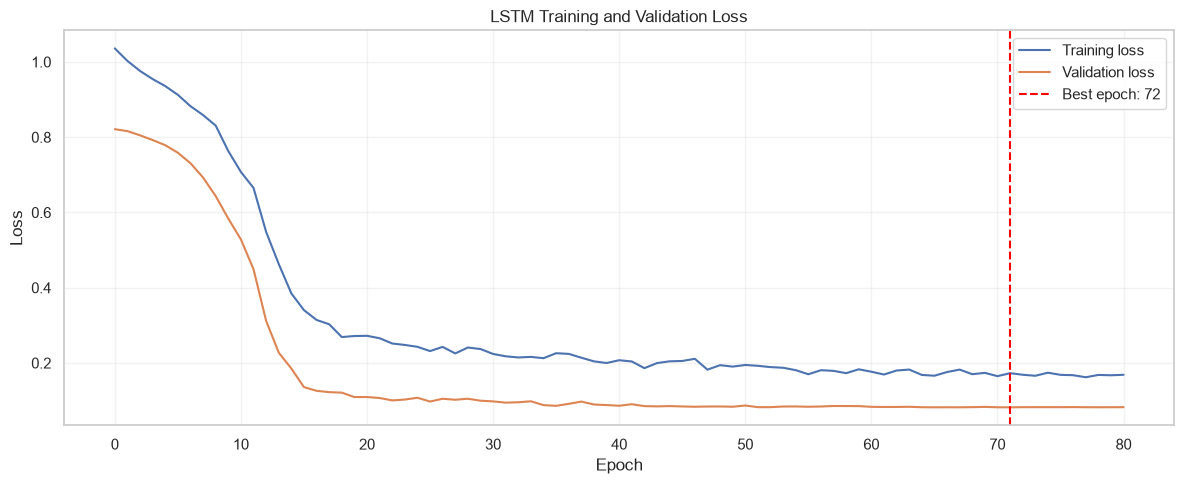

In [100]:
plt.figure(figsize=(12, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation loss"
)

plt.axvline(
    best_lstm_epoch - 1,
    color="red",
    linestyle="--",
    label=f"Best epoch: {best_lstm_epoch}"
)

plt.title(
    "LSTM Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [101]:
def inverse_lstm_values(
    scaled_values,
    fitted_scaler
):
    scaled_values = np.asarray(
        scaled_values,
        dtype=float
    ).reshape(-1, 1)

    log_revenue = (
        fitted_scaler
        .inverse_transform(
            scaled_values
        )
        .ravel()
    )

    revenue = np.expm1(
        log_revenue
    )

    return np.clip(
        revenue,
        a_min=0,
        a_max=None
    )

In [102]:
lstm_validation_prediction_scaled = (
    lstm_model.predict(
        X_lstm_validation,
        verbose=0
    )
)

lstm_validation_prediction = (
    inverse_lstm_values(
        lstm_validation_prediction_scaled,
        lstm_scaler
    )
)

lstm_validation_actual = (
    inverse_lstm_values(
        y_lstm_validation,
        lstm_scaler
    )
)

lstm_validation_target_dates = (
    lstm_target_dates[
        lstm_validation_mask
    ]
)

print(
    "Validation observations:",
    len(lstm_validation_actual)
)

print(
    "Validation dates:",
    lstm_validation_target_dates.min(),
    "to",
    lstm_validation_target_dates.max()
)

Validation observations: 92
Validation dates: 2011-06-01 00:00:00 to 2011-08-31 00:00:00


In [103]:
lstm_validation_actual = np.asarray(
    y_forecast_validation_raw,
    dtype=float
).ravel()

lstm_validation_actual[
    np.isclose(
        lstm_validation_actual,
        0,
        atol=1e-8
    )
] = 0.0

assert len(lstm_validation_actual) == 92


In [104]:
best_xgb_validation_prediction = np.clip(
    best_xgb_validation_model.predict(
        X_forecast_validation
    ),
    a_min=0,
    a_max=None
)

In [105]:
baseline_validation_metrics = (
    calculate_forecast_metrics(
        lstm_validation_actual,
        validation_baseline_prediction
    )
)

xgb_validation_metrics = (
    calculate_forecast_metrics(
        lstm_validation_actual,
        best_xgb_validation_prediction
    )
)

lstm_validation_metrics = (
    calculate_forecast_metrics(
        lstm_validation_actual,
        lstm_validation_prediction
    )
)

complete_validation_comparison = pd.DataFrame([
    {
        "Model": "SameWeekday4WeekAverage",
        **baseline_validation_metrics
    },
    {
        "Model": "Tuned XGBoost Raw Target",
        **xgb_validation_metrics
    },
    {
        "Model": "LSTM 30-Day Sequence",
        **lstm_validation_metrics
    }
]).set_index("Model")

complete_validation_comparison.sort_values(
    "WAPEPercent"
).round(3)

,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent
Model,,,,,,
SameWeekday4WeekAverage,92,7774.359,10963.697,33.625,36.561,1.281
Tuned XGBoost Raw Target,92,7978.098,11376.619,34.507,56.482,-7.556
LSTM 30-Day Sequence,92,9744.473,13823.721,42.146,59.597,-8.293


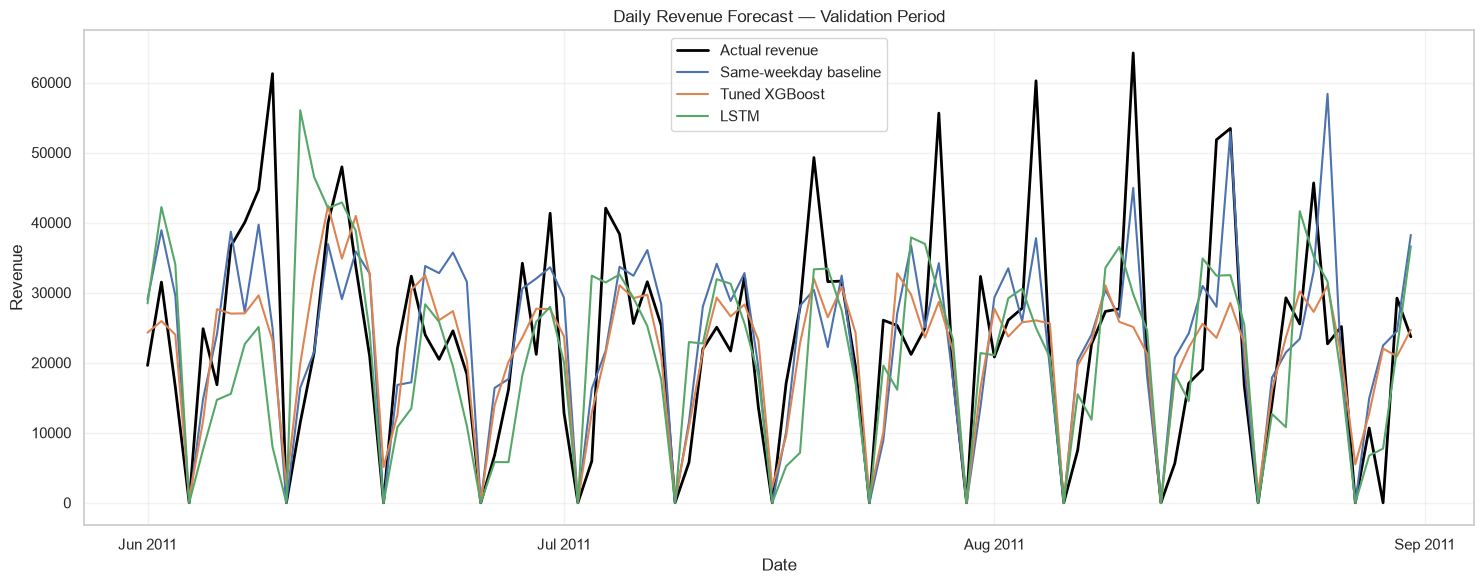

In [106]:
validation_forecast_results = pd.DataFrame(
    {
        "ActualRevenue": (
            lstm_validation_actual
        ),
        "BaselinePrediction": (
            validation_baseline_prediction
        ),
        "XGBoostPrediction": (
            best_xgb_validation_prediction
        ),
        "LSTMPrediction": (
            lstm_validation_prediction
        )
    },
    index=lstm_validation_target_dates
)

fig, ax = plt.subplots(
    figsize=(15, 6)
)

ax.plot(
    validation_forecast_results.index,
    validation_forecast_results[
        "ActualRevenue"
    ],
    color="black",
    linewidth=2,
    label="Actual revenue"
)

ax.plot(
    validation_forecast_results.index,
    validation_forecast_results[
        "BaselinePrediction"
    ],
    label="Same-weekday baseline"
)

ax.plot(
    validation_forecast_results.index,
    validation_forecast_results[
        "XGBoostPrediction"
    ],
    label="Tuned XGBoost"
)

ax.plot(
    validation_forecast_results.index,
    validation_forecast_results[
        "LSTMPrediction"
    ],
    label="LSTM"
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

ax.set_title(
    "Daily Revenue Forecast — Validation Period"
)

ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [107]:
final_lstm_development_mask = (
    lstm_revenue_series.index
    < lstm_test_start
)

final_lstm_log_revenue = np.log1p(
    lstm_revenue_series.to_numpy(
        dtype=float
    )
).reshape(-1, 1)

final_lstm_scaler = StandardScaler()

final_lstm_scaler.fit(
    final_lstm_log_revenue[
        final_lstm_development_mask
    ]
)

final_lstm_scaled_revenue = (
    final_lstm_scaler.transform(
        final_lstm_log_revenue
    )
)

print(
    "Final scaler observations:",
    final_lstm_development_mask.sum()
)

Final scaler observations: 583


In [108]:
(
    X_lstm_final_all,
    y_lstm_final_all,
    lstm_final_target_dates
) = create_lstm_sequences(
    scaled_values=final_lstm_scaled_revenue,
    dates=lstm_revenue_series.index,
    lookback_days=LSTM_LOOKBACK_DAYS
)

final_development_sequence_mask = (
    lstm_final_target_dates
    < lstm_test_start
)

final_test_sequence_mask = (
    (lstm_final_target_dates >= lstm_test_start)
    &
    (lstm_final_target_dates <= lstm_test_end)
)

X_lstm_final_development = (
    X_lstm_final_all[
        final_development_sequence_mask
    ]
)

y_lstm_final_development = (
    y_lstm_final_all[
        final_development_sequence_mask
    ]
)

X_lstm_final_test = (
    X_lstm_final_all[
        final_test_sequence_mask
    ]
)

lstm_final_test_dates = (
    lstm_final_target_dates[
        final_test_sequence_mask
    ]
)

print(
    "Development sequences:",
    X_lstm_final_development.shape
)

print(
    "Final test sequences:",
    X_lstm_final_test.shape
)

print(
    "Test dates:",
    lstm_final_test_dates.min(),
    "to",
    lstm_final_test_dates.max()
)

assert len(X_lstm_final_test) == 91

Development sequences: (553, 30, 1)
Final test sequences: (91, 30, 1)
Test dates: 2011-09-01 00:00:00 to 2011-11-30 00:00:00


In [109]:
def build_final_lstm_model():
    model = Sequential(
        [
            Input(
                shape=(
                    LSTM_LOOKBACK_DAYS,
                    1
                )
            ),

            LSTM(
                units=32,
                return_sequences=False
            ),

            Dropout(rate=0.20),

            Dense(
                units=16,
                activation="relu"
            ),

            Dense(units=1)
        ],
        name="final_daily_revenue_lstm"
    )

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [110]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

final_lstm_model = (
    build_final_lstm_model()
)

final_lstm_history = final_lstm_model.fit(
    X_lstm_final_development,
    y_lstm_final_development,
    epochs=int(best_lstm_epoch),
    batch_size=16,
    shuffle=False,
    verbose=1
)


Epoch 1/72
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.0255 - mae: 0.7451
Epoch 2/72
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9893 - mae: 0.7436
Epoch 3/72
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9644 - mae: 0.7330
Epoch 4/72
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9418 - mae: 0.7306
Epoch 5/72
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9215 - mae: 0.7161
Epoch 6/72
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8858 - mae: 0.7052
Epoch 7/72
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8434 - mae: 0.6821
Epoch 8/72
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7813 - mae: 0.6471
Epoch 9/72
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6928 - mae: 0.5898
Epoch 10/72
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6411 - mae: 0.5514
Epoch 11/72
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5758 - mae: 0.5116
Epoch 12/72
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5325 - mae: 0.4845
Epoch 13/72
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/st

In [111]:
final_lstm_test_prediction_scaled = (
    final_lstm_model.predict(
        X_lstm_final_test,
        verbose=0
    )
)

final_lstm_test_prediction = (
    inverse_lstm_values(
        final_lstm_test_prediction_scaled,
        final_lstm_scaler
    )
)

final_lstm_test_actual = np.asarray(
    y_forecast_test_raw,
    dtype=float
).ravel()

final_lstm_test_actual[
    np.isclose(
        final_lstm_test_actual,
        0,
        atol=1e-8
    )
] = 0.0

assert len(final_lstm_test_prediction) == 91
assert len(final_lstm_test_actual) == 91

In [112]:
baseline_final_test_metrics = (
    calculate_forecast_metrics(
        final_lstm_test_actual,
        baseline_test_prediction
    )
)

xgb_final_test_metrics = (
    calculate_forecast_metrics(
        final_lstm_test_actual,
        xgb_test_prediction
    )
)

lstm_final_test_metrics = (
    calculate_forecast_metrics(
        final_lstm_test_actual,
        final_lstm_test_prediction
    )
)

final_forecasting_comparison = pd.DataFrame([
    {
        "Model": "SameWeekday4WeekAverage",
        **baseline_final_test_metrics
    },
    {
        "Model": "Tuned XGBoost Raw Target",
        **xgb_final_test_metrics
    },
    {
        "Model": "LSTM 30-Day Sequence",
        **lstm_final_test_metrics
    }
]).set_index("Model")

final_forecasting_comparison[
    "WAPERank"
] = (
    final_forecasting_comparison[
        "WAPEPercent"
    ]
    .rank(
        method="min"
    )
    .astype(int)
)

final_forecasting_comparison.sort_values(
    "WAPEPercent"
).round(3)

,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent,WAPERank
Model,,,,,,,
Tuned XGBoost Raw Target,91,9800.317,14121.721,25.287,51.345,-2.675,1
SameWeekday4WeekAverage,91,12068.298,16978.475,31.138,33.967,-12.418,2
LSTM 30-Day Sequence,91,20272.255,27115.922,52.306,85.758,-50.139,3


In [113]:
final_forecasting_winner = (
    final_forecasting_comparison[
        "WAPEPercent"
    ].idxmin()
)

print(
    "Selected forecasting model:",
    final_forecasting_winner
)

Selected forecasting model: Tuned XGBoost Raw Target


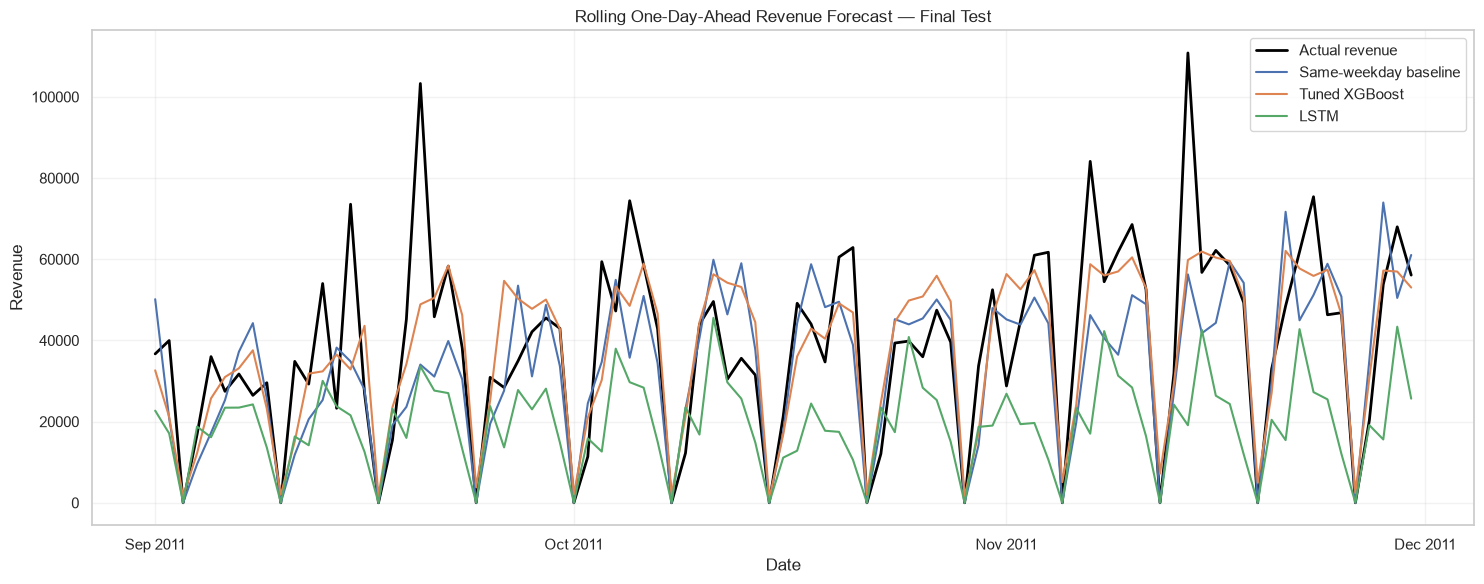

In [114]:
final_forecast_results = pd.DataFrame(
    {
        "ActualRevenue": (
            final_lstm_test_actual
        ),
        "BaselinePrediction": (
            baseline_test_prediction
        ),
        "XGBoostPrediction": (
            xgb_test_prediction
        ),
        "LSTMPrediction": (
            final_lstm_test_prediction
        )
    },
    index=lstm_final_test_dates
)

fig, ax = plt.subplots(
    figsize=(15, 6)
)

ax.plot(
    final_forecast_results.index,
    final_forecast_results[
        "ActualRevenue"
    ],
    color="black",
    linewidth=2,
    label="Actual revenue"
)

ax.plot(
    final_forecast_results.index,
    final_forecast_results[
        "BaselinePrediction"
    ],
    label="Same-weekday baseline"
)

ax.plot(
    final_forecast_results.index,
    final_forecast_results[
        "XGBoostPrediction"
    ],
    label="Tuned XGBoost"
)

ax.plot(
    final_forecast_results.index,
    final_forecast_results[
        "LSTMPrediction"
    ],
    label="LSTM"
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

ax.set_title(
    "Rolling One-Day-Ahead Revenue Forecast — Final Test"
)

ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [115]:
from pathlib import Path
import json
import joblib

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

forecast_table_folder = (
    project_root
    / "reports"
    / "tables"
)

forecast_figure_folder = (
    project_root
    / "reports"
    / "figures"
)

model_folder = (
    project_root
    / "models"
)

forecast_table_folder.mkdir(
    parents=True,
    exist_ok=True
)

forecast_figure_folder.mkdir(
    parents=True,
    exist_ok=True
)

model_folder.mkdir(
    parents=True,
    exist_ok=True
)

In [116]:
forecast_comparison_file = (
    forecast_table_folder
    / "forecast_model_comparison.csv"
)

(
    final_forecasting_comparison
    .reset_index()
    .to_csv(
        forecast_comparison_file,
        index=False
    )
)

In [117]:
forecast_predictions_file = (
    forecast_table_folder
    / "forecast_test_predictions.csv"
)

forecast_predictions_export = (
    final_forecast_results
    .rename_axis("ForecastDate")
    .reset_index()
)

forecast_predictions_export.to_csv(
    forecast_predictions_file,
    index=False
)

In [118]:
forecast_figure_file = (
    forecast_figure_folder
    / "forecast_test_comparison.png"
)

fig.savefig(
    forecast_figure_file,
    dpi=300,
    bbox_inches="tight"
)

In [119]:
xgb_model_file = (
    model_folder
    / "final_xgb_forecast_model.joblib"
)

joblib.dump(
    final_xgb_forecast_model,
    xgb_model_file
)

['c:\\Github\\retail-financial-intelligence\\models\\final_xgb_forecast_model.joblib']

In [120]:
lstm_model_file = (
    model_folder
    / "final_lstm_forecast_model.keras"
)

final_lstm_model.save(
    lstm_model_file
)

In [121]:
lstm_scaler_file = (
    model_folder
    / "final_lstm_scaler.joblib"
)

joblib.dump(
    final_lstm_scaler,
    lstm_scaler_file
)

['c:\\Github\\retail-financial-intelligence\\models\\final_lstm_scaler.joblib']

In [122]:
forecast_metadata = {
    "forecast_grain": "daily",
    "forecast_type": (
        "rolling one-day-ahead"
    ),
    "validation_start": (
        str(lstm_validation_start.date())
    ),
    "test_start": (
        str(lstm_test_start.date())
    ),
    "test_end": (
        str(lstm_test_end.date())
    ),
    "partial_december_excluded": True,
    "lstm_lookback_days": int(
        LSTM_LOOKBACK_DAYS
    ),
    "lstm_selected_epochs": int(
        best_lstm_epoch
    ),
    "selected_model": (
        final_forecasting_winner
    ),
    "primary_selection_metric": (
        "WAPEPercent"
    ),
    "xgboost_parameters": (
        best_xgb_parameters
    )
}

forecast_metadata_file = (
    model_folder
    / "forecast_metadata.json"
)

with open(
    forecast_metadata_file,
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        forecast_metadata,
        metadata_file,
        indent=4
    )

In [123]:
saved_forecasting_files = [
    forecast_comparison_file,
    forecast_predictions_file,
    forecast_figure_file,
    xgb_model_file,
    lstm_model_file,
    lstm_scaler_file,
    forecast_metadata_file
]

for saved_file in saved_forecasting_files:
    print(
        saved_file.name,
        "→",
        saved_file.exists(),
        "→",
        round(
            saved_file.stat().st_size
            / 1024,
            2
        ),
        "KB"
    )

forecast_model_comparison.csv → True → 0.43 KB
forecast_test_predictions.csv → True → 6.1 KB
forecast_test_comparison.png → True → 728.1 KB
final_xgb_forecast_model.joblib → True → 271.11 KB
final_lstm_forecast_model.keras → True → 88.04 KB
final_lstm_scaler.joblib → True → 0.58 KB
forecast_metadata.json → True → 0.53 KB


In [124]:
print(final_forecasting_winner)

Tuned XGBoost Raw Target


In [125]:
if hasattr(
    final_xgb_forecast_model,
    "feature_names_in_"
):
    model_feature_names = list(
        final_xgb_forecast_model
        .feature_names_in_
    )
else:
    model_feature_names = (
        final_xgb_forecast_model
        .get_booster()
        .feature_names
    )

if model_feature_names is None:
    model_feature_names = list(
        forecast_feature_columns
    )

feature_audit = pd.DataFrame({
    "ModelFeature": pd.Series(
        model_feature_names
    ),
    "NotebookFeature": pd.Series(
        forecast_feature_columns
    )
})

feature_audit["Matches"] = (
    feature_audit["ModelFeature"]
    == feature_audit["NotebookFeature"]
)

print(
    "Model feature count:",
    len(model_feature_names)
)

print(
    "Notebook feature count:",
    len(forecast_feature_columns)
)

print(
    "Exact order match:",
    bool(
        feature_audit["Matches"].all()
    )
)

feature_audit

Model feature count: 31
Notebook feature count: 31
Exact order match: True


,ModelFeature,NotebookFeature,Matches
0,DayOfWeek,DayOfWeek,True
1,DayOfMonth,DayOfMonth,True
2,DayOfYear,DayOfYear,True
3,WeekOfYear,WeekOfYear,True
4,Month,Month,True
5,Quarter,Quarter,True
6,IsSaturday,IsSaturday,True
7,IsSunday,IsSunday,True
8,TimeIndex,TimeIndex,True
9,DayOfWeekSin,DayOfWeekSin,True


In [126]:
print(
    "Last complete historical date:",
    lstm_revenue_series.index.max()
)

print(
    "First future forecast date:",
    lstm_revenue_series.index.max()
    + pd.Timedelta(days=1)
)

lstm_revenue_series.tail(35)

Last complete historical date: 2011-11-30 00:00:00
First future forecast date: 2011-12-01 00:00:00


SalesDate
2011-10-27     47458.98
2011-10-28     39580.53
2011-10-29         0.00
2011-10-30     33727.46
2011-10-31     52477.93
2011-11-01     28778.10
2011-11-02     44779.34
2011-11-03     60985.40
2011-11-04     61717.02
2011-11-05         0.00
2011-11-06     41788.65
2011-11-07     84108.61
2011-11-08     54460.73
2011-11-09     61832.81
2011-11-10     68543.27
2011-11-11     52506.38
2011-11-12         0.00
2011-11-13     31933.92
2011-11-14    110815.68
2011-11-15     56754.48
2011-11-16     62170.78
2011-11-17     58511.76
2011-11-18     49306.15
2011-11-19         0.00
2011-11-20     32954.31
2011-11-21     48471.06
2011-11-22     61849.30
2011-11-23     75395.90
2011-11-24     46316.16
2011-11-25     46814.87
2011-11-26         0.00
2011-11-27     20273.09
2011-11-28     53823.15
2011-11-29     67977.35
2011-11-30     56088.10
Name: Revenue, dtype: float64

In [127]:
print(model_feature_names)

[np.str_('DayOfWeek'), np.str_('DayOfMonth'), np.str_('DayOfYear'), np.str_('WeekOfYear'), np.str_('Month'), np.str_('Quarter'), np.str_('IsSaturday'), np.str_('IsSunday'), np.str_('TimeIndex'), np.str_('DayOfWeekSin'), np.str_('DayOfWeekCos'), np.str_('MonthSin'), np.str_('MonthCos'), np.str_('RevenueLag1'), np.str_('RevenueLag2'), np.str_('RevenueLag3'), np.str_('RevenueLag7'), np.str_('RevenueLag14'), np.str_('RevenueLag21'), np.str_('RevenueLag28'), np.str_('RevenueRollingMean7'), np.str_('RevenueRollingStd7'), np.str_('RevenueRollingMean14'), np.str_('RevenueRollingStd14'), np.str_('RevenueRollingMean28'), np.str_('RevenueRollingStd28'), np.str_('RevenueRollingMean56'), np.str_('RevenueRollingStd56'), np.str_('SameWeekday4WeekAverage'), np.str_('RevenueEWMA7'), np.str_('RevenueEWMA28')]


In [128]:
xgb_all_complete_features = pd.concat(
    [
        X_forecast_train,
        X_forecast_validation,
        X_forecast_test
    ],
    axis=0
).sort_index()

In [129]:
xgb_all_complete_target = pd.concat(
    [
        pd.Series(
            y_forecast_train_raw,
            index=X_forecast_train.index
        ),
        pd.Series(
            y_forecast_validation_raw,
            index=X_forecast_validation.index
        ),
        pd.Series(
            y_forecast_test_raw,
            index=X_forecast_test.index
        )
    ]
).sort_index()

xgb_all_complete_target = (
    xgb_all_complete_target.loc[
        xgb_all_complete_features.index
    ]
)

In [130]:
assert (
    xgb_all_complete_features.index
    .equals(
        xgb_all_complete_target.index
    )
)

assert len(xgb_all_complete_features) == len(
    xgb_all_complete_target
)

print(
    "Complete training observations:",
    len(xgb_all_complete_features)
)

print(
    "Historical data ends:",
    lstm_revenue_series.index.max()
)

Complete training observations: 674
Historical data ends: 2011-11-30 00:00:00


In [131]:
refit_xgb_forecast_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="mae",
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=2.00,
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
    **best_xgb_parameters
)

In [132]:
refit_xgb_forecast_model.fit(
    xgb_all_complete_features,
    xgb_all_complete_target,
    verbose=False
)

print(
    "Final XGBoost refit completed."
)

Final XGBoost refit completed.


In [133]:
refit_feature_names = list(
    refit_xgb_forecast_model
    .feature_names_in_
)

refit_validation = pd.Series({
    "Training observations": len(
        xgb_all_complete_features
    ),
    "Expected features": len(
        forecast_feature_columns
    ),
    "Model features": len(
        refit_feature_names
    ),
    "Feature order matches": (
        refit_feature_names
        == list(forecast_feature_columns)
    ),
    "Last historical date correct": (
        lstm_revenue_series.index.max()
        == pd.Timestamp("2011-11-30")
    )
})

refit_validation

Training observations            674
Expected features                 31
Model features                    31
Feature order matches           True
Last historical date correct    True
dtype: object

In [134]:
refit_xgb_model_file = (
    model_folder
    / "refit_xgb_forecast_model.joblib"
)

joblib.dump(
    refit_xgb_forecast_model,
    refit_xgb_model_file
)

print(
    "Saved:",
    refit_xgb_model_file
)

Saved: c:\Github\retail-financial-intelligence\models\refit_xgb_forecast_model.joblib


In [135]:
print(refit_feature_names)

[np.str_('DayOfWeek'), np.str_('DayOfMonth'), np.str_('DayOfYear'), np.str_('WeekOfYear'), np.str_('Month'), np.str_('Quarter'), np.str_('IsSaturday'), np.str_('IsSunday'), np.str_('TimeIndex'), np.str_('DayOfWeekSin'), np.str_('DayOfWeekCos'), np.str_('MonthSin'), np.str_('MonthCos'), np.str_('RevenueLag1'), np.str_('RevenueLag2'), np.str_('RevenueLag3'), np.str_('RevenueLag7'), np.str_('RevenueLag14'), np.str_('RevenueLag21'), np.str_('RevenueLag28'), np.str_('RevenueRollingMean7'), np.str_('RevenueRollingStd7'), np.str_('RevenueRollingMean14'), np.str_('RevenueRollingStd14'), np.str_('RevenueRollingMean28'), np.str_('RevenueRollingStd28'), np.str_('RevenueRollingMean56'), np.str_('RevenueRollingStd56'), np.str_('SameWeekday4WeekAverage'), np.str_('RevenueEWMA7'), np.str_('RevenueEWMA28')]


In [136]:
import re
import numpy as np
import pandas as pd
import matplotlib.dates as mdates

FUTURE_FORECAST_DAYS = 30

recursive_revenue_history = (
    lstm_revenue_series
    .copy()
    .sort_index()
    .astype(float)
)

last_historical_date = (
    recursive_revenue_history.index.max()
)

future_forecast_dates = pd.date_range(
    start=(
        last_historical_date
        + pd.Timedelta(days=1)
    ),
    periods=FUTURE_FORECAST_DAYS,
    freq="D"
)

print("Historical end:", last_historical_date)

print(
    "Forecast period:",
    future_forecast_dates.min(),
    "to",
    future_forecast_dates.max()
)

Historical end: 2011-11-30 00:00:00
Forecast period: 2011-12-01 00:00:00 to 2011-12-30 00:00:00


In [137]:
if "TimeIndex" in refit_feature_names:
    feature_date_candidates = [
        column
        for column in [
            "SalesDate",
            "Date",
            "InvoiceDate",
            "ForecastDate"
        ]
        if column in forecast_model_df.columns
    ]

    if not feature_date_candidates:
        raise ValueError(
            "Date column not found in "
            "forecast_model_df."
        )

    feature_date_column = (
        feature_date_candidates[0]
    )

    time_index_lookup = (
        forecast_model_df
        .assign(
            _ForecastDate=pd.to_datetime(
                forecast_model_df[
                    feature_date_column
                ]
            )
        )
        .sort_values("_ForecastDate")
    )

    last_time_index = int(
        time_index_lookup.loc[
            time_index_lookup[
                "_ForecastDate"
            ] <= last_historical_date,
            "TimeIndex"
        ].iloc[-1]
    )
else:
    last_time_index = (
        len(recursive_revenue_history)
        - 1
    )

print("Last TimeIndex:", last_time_index)

Last TimeIndex: 729


In [138]:
def build_recursive_xgb_features(
    forecast_date,
    revenue_history,
    time_index,
    required_features
):
    forecast_date = pd.Timestamp(
        forecast_date
    )

    day_of_week = (
        forecast_date.dayofweek
    )

    month = forecast_date.month

    calendar_values = {
        "Year": forecast_date.year,
        "Month": month,
        "Quarter": forecast_date.quarter,
        "DayOfMonth": forecast_date.day,
        "DayOfWeek": day_of_week,
        "DayOfYear": forecast_date.dayofyear,
        "WeekOfYear": int(
            forecast_date.isocalendar().week
        ),
        "IsMonday": int(day_of_week == 0),
        "IsSaturday": int(day_of_week == 5),
        "IsSunday": int(day_of_week == 6),
        "IsWeekend": int(day_of_week >= 5),
        "IsBusinessDay": int(
            day_of_week < 5
        ),
        "IsMonthStart": int(
            forecast_date.is_month_start
        ),
        "IsMonthEnd": int(
            forecast_date.is_month_end
        ),
        "IsQuarterStart": int(
            forecast_date.is_quarter_start
        ),
        "IsQuarterEnd": int(
            forecast_date.is_quarter_end
        ),
        "TimeIndex": time_index,
        "Trend": time_index,
        "DaysFromStart": time_index,

        "DayOfWeekSin": np.sin(
            2 * np.pi
            * day_of_week / 7
        ),
        "DayOfWeekCos": np.cos(
            2 * np.pi
            * day_of_week / 7
        ),
        "MonthSin": np.sin(
            2 * np.pi
            * month / 12
        ),
        "MonthCos": np.cos(
            2 * np.pi
            * month / 12
        ),
        "DayOfYearSin": np.sin(
            2 * np.pi
            * forecast_date.dayofyear
            / 365.25
        ),
        "DayOfYearCos": np.cos(
            2 * np.pi
            * forecast_date.dayofyear
            / 365.25
        )
    }

    feature_values = {}
    unsupported_features = []

    for feature in required_features:
        if feature in calendar_values:
            feature_values[feature] = (
                calendar_values[feature]
            )
            continue

        lag_match = re.fullmatch(
            r"RevenueLag(\d+)",
            feature
        )

        if lag_match:
            lag_days = int(
                lag_match.group(1)
            )

            lag_date = (
                forecast_date
                - pd.Timedelta(
                    days=lag_days
                )
            )

            feature_values[feature] = (
                revenue_history.loc[
                    lag_date
                ]
            )

            continue

        rolling_mean_match = re.fullmatch(
            r"RevenueRollingMean(\d+)",
            feature
        )

        if rolling_mean_match:
            window = int(
                rolling_mean_match.group(1)
            )

            feature_values[feature] = (
                revenue_history
                .iloc[-window:]
                .mean()
            )

            continue

        rolling_std_match = re.fullmatch(
            r"RevenueRollingStd(\d+)",
            feature
        )

        if rolling_std_match:
            window = int(
                rolling_std_match.group(1)
            )

            feature_values[feature] = (
                revenue_history
                .iloc[-window:]
                .std()
            )

            continue

        rolling_median_match = re.fullmatch(
            r"RevenueRollingMedian(\d+)",
            feature
        )

        if rolling_median_match:
            window = int(
                rolling_median_match.group(1)
            )

            feature_values[feature] = (
                revenue_history
                .iloc[-window:]
                .median()
            )

            continue

        ewma_match = re.fullmatch(
            r"RevenueEWMA(\d+)",
            feature
        )

        if ewma_match:
            span = int(
                ewma_match.group(1)
            )

            feature_values[feature] = (
                revenue_history
                .ewm(
                    span=span,
                    adjust=False
                )
                .mean()
                .iloc[-1]
            )

            continue

        if feature == (
            "SameWeekday4WeekAverage"
        ):
            same_weekday_values = [
                revenue_history.loc[
                    forecast_date
                    - pd.Timedelta(days=lag)
                ]
                for lag in [
                    7,
                    14,
                    21,
                    28
                ]
            ]

            feature_values[feature] = (
                np.mean(
                    same_weekday_values
                )
            )

            continue

        if feature == "RevenueExpandingMean":
            feature_values[feature] = (
                revenue_history.mean()
            )
            continue

        if feature == "RevenueExpandingStd":
            feature_values[feature] = (
                revenue_history.std()
            )
            continue

        unsupported_features.append(
            feature
        )

    if unsupported_features:
        raise ValueError(
            "Feature formulas are missing for: "
            f"{unsupported_features}"
        )

    feature_row = pd.DataFrame(
        [feature_values],
        columns=required_features
    )

    return feature_row.astype(float)

In [139]:
first_future_feature_row = (
    build_recursive_xgb_features(
        forecast_date=(
            future_forecast_dates[0]
        ),
        revenue_history=(
            recursive_revenue_history
        ),
        time_index=(
            last_time_index + 1
        ),
        required_features=(
            refit_feature_names
        )
    )
)

assert list(
    first_future_feature_row.columns
) == refit_feature_names

assert (
    first_future_feature_row
    .isna()
    .sum()
    .sum()
    == 0
)

first_future_feature_row.T

,0
DayOfWeek,3.000000e+00
DayOfMonth,1.000000e+00
DayOfYear,3.350000e+02
WeekOfYear,4.800000e+01
Month,1.200000e+01
Quarter,4.000000e+00
IsSaturday,0.000000e+00
IsSunday,0.000000e+00
TimeIndex,7.300000e+02
DayOfWeekSin,4.338837e-01


In [140]:
recursive_forecast_records = []

for horizon_day, forecast_date in enumerate(
    future_forecast_dates,
    start=1
):
    future_feature_row = (
        build_recursive_xgb_features(
            forecast_date=forecast_date,
            revenue_history=(
                recursive_revenue_history
            ),
            time_index=(
                last_time_index
                + horizon_day
            ),
            required_features=(
                refit_feature_names
            )
        )
    )

    predicted_revenue = float(
        refit_xgb_forecast_model.predict(
            future_feature_row
        )[0]
    )

    predicted_revenue = max(
        predicted_revenue,
        0.0
    )

    recursive_forecast_records.append({
        "ForecastDate": forecast_date,
        "ForecastHorizonDay": (
            horizon_day
        ),
        "PredictedRevenue": (
            predicted_revenue
        ),
        "Model": (
            "Tuned XGBoost "
            "Recursive Forecast"
        )
    })

    recursive_revenue_history.loc[
        forecast_date
    ] = predicted_revenue

In [141]:
future_revenue_forecast = pd.DataFrame(
    recursive_forecast_records
)

future_revenue_forecast.head(10)

,ForecastDate,ForecastHorizonDay,PredictedRevenue,Model
0,2011-12-01,1,54200.878906,Tuned XGBoost Recursive Forecast
1,2011-12-02,2,47685.371094,Tuned XGBoost Recursive Forecast
2,2011-12-03,3,5033.153809,Tuned XGBoost Recursive Forecast
3,2011-12-04,4,30759.994141,Tuned XGBoost Recursive Forecast
4,2011-12-05,5,61334.589844,Tuned XGBoost Recursive Forecast
5,2011-12-06,6,60961.378906,Tuned XGBoost Recursive Forecast
6,2011-12-07,7,56168.742188,Tuned XGBoost Recursive Forecast
7,2011-12-08,8,56605.046875,Tuned XGBoost Recursive Forecast
8,2011-12-09,9,49832.910156,Tuned XGBoost Recursive Forecast
9,2011-12-10,10,5707.412109,Tuned XGBoost Recursive Forecast


In [142]:
future_forecast_validation = pd.Series({
    "Forecast rows": len(
        future_revenue_forecast
    ),
    "Missing predictions": (
        future_revenue_forecast[
            "PredictedRevenue"
        ].isna().sum()
    ),
    "Negative predictions": (
        future_revenue_forecast[
            "PredictedRevenue"
        ].lt(0).sum()
    ),
    "Forecast start correct": (
        future_revenue_forecast[
            "ForecastDate"
        ].min()
        == pd.Timestamp("2011-12-01")
    ),
    "Forecast end correct": (
        future_revenue_forecast[
            "ForecastDate"
        ].max()
        == pd.Timestamp("2011-12-30")
    ),
    "Total forecast revenue": (
        future_revenue_forecast[
            "PredictedRevenue"
        ].sum()
    )
})

future_forecast_validation

Forecast rows                         30
Missing predictions                    0
Negative predictions                   0
Forecast start correct              True
Forecast end correct                True
Total forecast revenue    1280806.034424
dtype: object

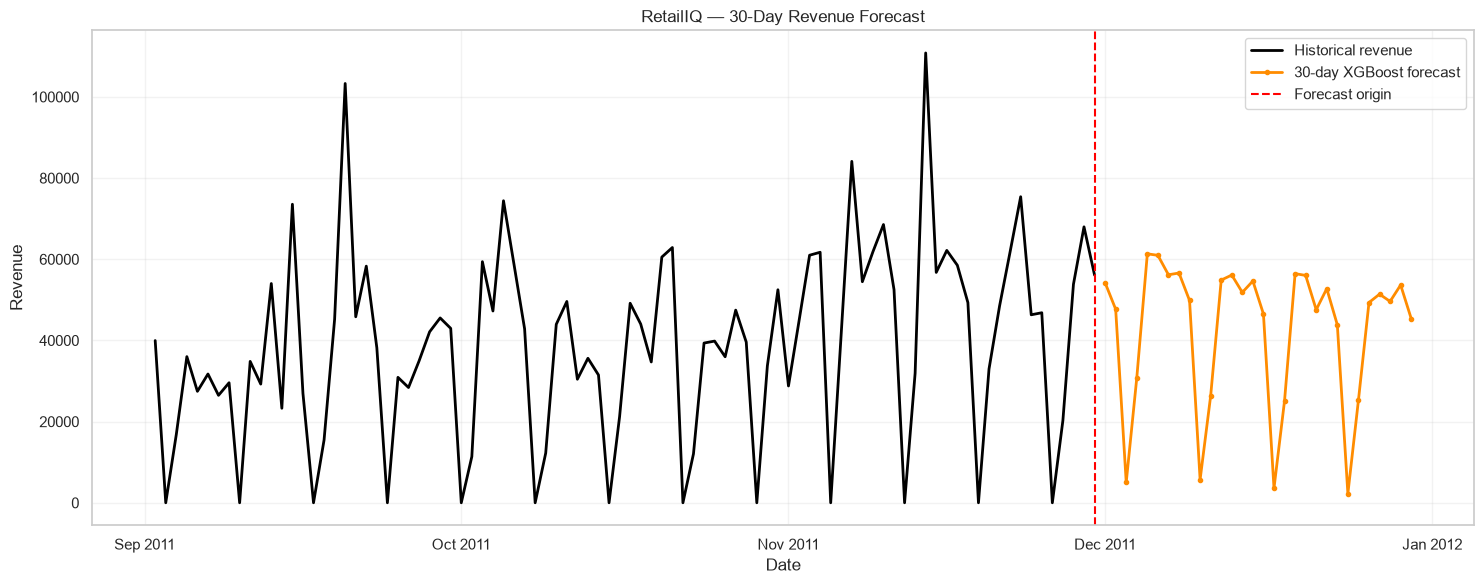

In [143]:
historical_plot_data = (
    lstm_revenue_series
    .tail(90)
)

fig, ax = plt.subplots(
    figsize=(15, 6)
)

ax.plot(
    historical_plot_data.index,
    historical_plot_data.values,
    color="black",
    linewidth=2,
    label="Historical revenue"
)

ax.plot(
    future_revenue_forecast[
        "ForecastDate"
    ],
    future_revenue_forecast[
        "PredictedRevenue"
    ],
    color="darkorange",
    linewidth=2,
    marker="o",
    markersize=3,
    label="30-day XGBoost forecast"
)

ax.axvline(
    last_historical_date,
    color="red",
    linestyle="--",
    label="Forecast origin"
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

ax.set_title(
    "RetailIQ — 30-Day Revenue Forecast"
)

ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [144]:
xgb_validation_residuals = (
    lstm_validation_actual
    - best_xgb_validation_prediction
)

residual_lower_quantile = np.quantile(
    xgb_validation_residuals,
    0.10
)

residual_upper_quantile = np.quantile(
    xgb_validation_residuals,
    0.90
)

print(
    "10th percentile residual:",
    round(residual_lower_quantile, 2)
)

print(
    "90th percentile residual:",
    round(residual_upper_quantile, 2)
)

10th percentile residual: -8481.91
90th percentile residual: 15994.42


In [145]:
future_revenue_forecast[
    "LowerRevenueEstimate"
] = np.clip(
    future_revenue_forecast[
        "PredictedRevenue"
    ]
    + residual_lower_quantile,
    a_min=0,
    a_max=None
)

future_revenue_forecast[
    "UpperRevenueEstimate"
] = (
    future_revenue_forecast[
        "PredictedRevenue"
    ]
    + residual_upper_quantile
)

future_revenue_forecast.head()

,ForecastDate,ForecastHorizonDay,PredictedRevenue,Model,LowerRevenueEstimate,UpperRevenueEstimate
0,2011-12-01,1,54200.878906,Tuned XGBoost Recursive Forecast,45718.969969,70195.299094
1,2011-12-02,2,47685.371094,Tuned XGBoost Recursive Forecast,39203.462156,63679.791281
2,2011-12-03,3,5033.153809,Tuned XGBoost Recursive Forecast,0.000000,21027.573996
3,2011-12-04,4,30759.994141,Tuned XGBoost Recursive Forecast,22278.085203,46754.414328
4,2011-12-05,5,61334.589844,Tuned XGBoost Recursive Forecast,52852.680906,77329.010031


In [146]:
highest_forecast_row = (
    future_revenue_forecast.loc[
        future_revenue_forecast[
            "PredictedRevenue"
        ].idxmax()
    ]
)

lowest_forecast_row = (
    future_revenue_forecast.loc[
        future_revenue_forecast[
            "PredictedRevenue"
        ].idxmin()
    ]
)

future_forecast_summary = pd.Series({
    "Forecast days": len(
        future_revenue_forecast
    ),
    "Total predicted revenue": (
        future_revenue_forecast[
            "PredictedRevenue"
        ].sum()
    ),
    "Average daily revenue": (
        future_revenue_forecast[
            "PredictedRevenue"
        ].mean()
    ),
    "Median daily revenue": (
        future_revenue_forecast[
            "PredictedRevenue"
        ].median()
    ),
    "Highest forecast revenue": (
        highest_forecast_row[
            "PredictedRevenue"
        ]
    ),
    "Lowest forecast revenue": (
        lowest_forecast_row[
            "PredictedRevenue"
        ]
    )
})

future_forecast_summary.round(2)

Forecast days                    30.00
Total predicted revenue     1280806.03
Average daily revenue         42693.53
Median daily revenue          49720.04
Highest forecast revenue      61334.59
Lowest forecast revenue        2256.82
dtype: float64

In [147]:
print(
    "Highest forecast date:",
    highest_forecast_row[
        "ForecastDate"
    ]
)

print(
    "Lowest forecast date:",
    lowest_forecast_row[
        "ForecastDate"
    ]
)

Highest forecast date: 2011-12-05 00:00:00
Lowest forecast date: 2011-12-24 00:00:00


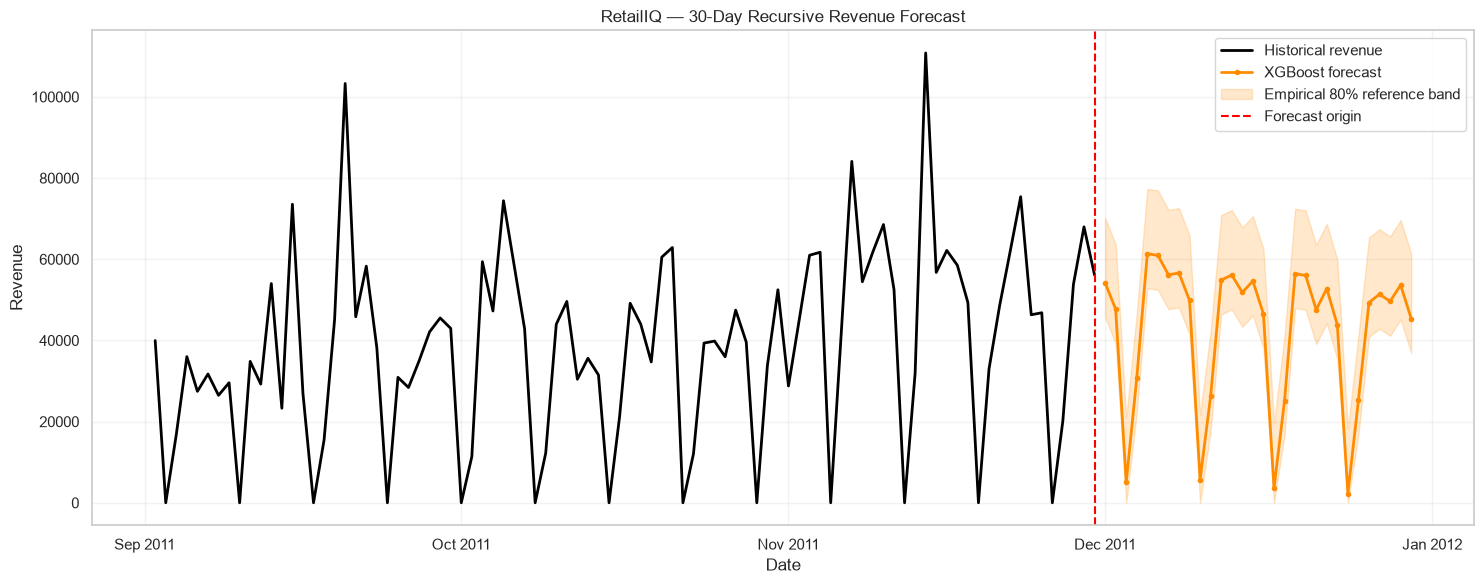

In [148]:
historical_plot_data = (
    lstm_revenue_series
    .tail(90)
)

future_fig, ax = plt.subplots(
    figsize=(15, 6)
)

ax.plot(
    historical_plot_data.index,
    historical_plot_data.values,
    color="black",
    linewidth=2,
    label="Historical revenue"
)

ax.plot(
    future_revenue_forecast[
        "ForecastDate"
    ],
    future_revenue_forecast[
        "PredictedRevenue"
    ],
    color="darkorange",
    linewidth=2,
    marker="o",
    markersize=3,
    label="XGBoost forecast"
)

ax.fill_between(
    future_revenue_forecast[
        "ForecastDate"
    ],
    future_revenue_forecast[
        "LowerRevenueEstimate"
    ],
    future_revenue_forecast[
        "UpperRevenueEstimate"
    ],
    color="darkorange",
    alpha=0.20,
    label="Empirical 80% reference band"
)

ax.axvline(
    last_historical_date,
    color="red",
    linestyle="--",
    label="Forecast origin"
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

ax.set_title(
    "RetailIQ — 30-Day Recursive Revenue Forecast"
)

ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [149]:
future_forecast_file = (
    forecast_table_folder
    / "future_30_day_revenue_forecast.csv"
)

future_revenue_forecast.to_csv(
    future_forecast_file,
    index=False
)

future_forecast_figure_file = (
    forecast_figure_folder
    / "future_30_day_revenue_forecast.png"
)

future_fig.savefig(
    future_forecast_figure_file,
    dpi=300,
    bbox_inches="tight"
)

In [150]:
refit_xgb_model_file = (
    model_folder
    / "refit_xgb_forecast_model.joblib"
)

joblib.dump(
    refit_xgb_forecast_model,
    refit_xgb_model_file
)

['c:\\Github\\retail-financial-intelligence\\models\\refit_xgb_forecast_model.joblib']

In [151]:
if forecast_metadata_file.exists():
    with open(
        forecast_metadata_file,
        "r",
        encoding="utf-8"
    ) as metadata_file:
        forecast_metadata = json.load(
            metadata_file
        )
else:
    forecast_metadata = {}

forecast_metadata.update({
    "deployment_model": (
        "Tuned XGBoost Raw Target"
    ),
    "historical_data_end": (
        str(
            last_historical_date.date()
        )
    ),
    "future_forecast_start": (
        str(
            future_forecast_dates.min().date()
        )
    ),
    "future_forecast_end": (
        str(
            future_forecast_dates.max().date()
        )
    ),
    "future_forecast_days": int(
        FUTURE_FORECAST_DAYS
    ),
    "forecast_strategy": (
        "recursive multi-step"
    ),
    "uncertainty_method": (
        "10th and 90th percentiles of "
        "validation residuals"
    )
})

with open(
    forecast_metadata_file,
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        forecast_metadata,
        metadata_file,
        indent=4
    )

In [152]:
if forecast_metadata_file.exists():
    with open(
        forecast_metadata_file,
        "r",
        encoding="utf-8"
    ) as metadata_file:
        forecast_metadata = json.load(
            metadata_file
        )
else:
    forecast_metadata = {}

forecast_metadata.update({
    "deployment_model": (
        "Tuned XGBoost Raw Target"
    ),
    "historical_data_end": (
        str(
            last_historical_date.date()
        )
    ),
    "future_forecast_start": (
        str(
            future_forecast_dates.min().date()
        )
    ),
    "future_forecast_end": (
        str(
            future_forecast_dates.max().date()
        )
    ),
    "future_forecast_days": int(
        FUTURE_FORECAST_DAYS
    ),
    "forecast_strategy": (
        "recursive multi-step"
    ),
    "uncertainty_method": (
        "10th and 90th percentiles of "
        "validation residuals"
    )
})

with open(
    forecast_metadata_file,
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        forecast_metadata,
        metadata_file,
        indent=4
    )

In [153]:
forecasting_completion_check = {
    "comparison_saved": (
        forecast_comparison_file.exists()
    ),
    "test_predictions_saved": (
        forecast_predictions_file.exists()
    ),
    "future_forecast_saved": (
        future_forecast_file.exists()
    ),
    "test_figure_saved": (
        forecast_figure_file.exists()
    ),
    "future_figure_saved": (
        future_forecast_figure_file.exists()
    ),
    "xgboost_model_saved": (
        refit_xgb_model_file.exists()
    ),
    "lstm_model_saved": (
        lstm_model_file.exists()
    ),
    "metadata_saved": (
        forecast_metadata_file.exists()
    ),
    "forecast_has_30_days": (
        len(future_revenue_forecast)
        == 30
    ),
    "no_missing_forecasts": (
        future_revenue_forecast[
            "PredictedRevenue"
        ].notna().all()
    )
}

forecasting_completion_check

{'comparison_saved': True,
 'test_predictions_saved': True,
 'future_forecast_saved': True,
 'test_figure_saved': True,
 'future_figure_saved': True,
 'xgboost_model_saved': True,
 'lstm_model_saved': True,
 'metadata_saved': True,
 'forecast_has_30_days': True,
 'no_missing_forecasts': np.True_}

In [154]:
baseline_name = (
    "SameWeekday4WeekAverage"
)

xgb_name = (
    "Tuned XGBoost Raw Target"
)

lstm_name = (
    "LSTM 30-Day Sequence"
)

baseline_result = (
    final_forecasting_comparison
    .loc[baseline_name]
)

xgb_result = (
    final_forecasting_comparison
    .loc[xgb_name]
)

lstm_result = (
    final_forecasting_comparison
    .loc[lstm_name]
)

xgb_wape_improvement = (
    (
        baseline_result["WAPEPercent"]
        - xgb_result["WAPEPercent"]
    )
    / baseline_result["WAPEPercent"]
    * 100
)

future_total_revenue = (
    future_revenue_forecast[
        "PredictedRevenue"
    ].sum()
)

future_average_revenue = (
    future_revenue_forecast[
        "PredictedRevenue"
    ].mean()
)

In [155]:
from IPython.display import (
    display,
    Markdown
)

forecasting_report_markdown = f"""
## Forecasting Executive Summary

RetailIQ compared three daily revenue forecasting approaches:

1. A same-weekday four-week seasonal baseline
2. A tuned XGBoost regression model
3. A 30-day sequence LSTM model

The models were developed using chronological training and validation
periods and evaluated on the final complete test period from
September to November 2011. Partial December 2011 was excluded from
model evaluation.

The selected model was **{final_forecasting_winner}**, based primarily
on the lowest test WAPE.

### Final Test Performance

| Model | MAE | RMSE | WAPE | SMAPE | Bias |
|---|---:|---:|---:|---:|---:|
| Same-weekday baseline | {baseline_result["MAE"]:,.2f} | {baseline_result["RMSE"]:,.2f} | {baseline_result["WAPEPercent"]:.2f}% | {baseline_result["SMAPEPercent"]:.2f}% | {baseline_result["BiasPercent"]:.2f}% |
| Tuned XGBoost | {xgb_result["MAE"]:,.2f} | {xgb_result["RMSE"]:,.2f} | {xgb_result["WAPEPercent"]:.2f}% | {xgb_result["SMAPEPercent"]:.2f}% | {xgb_result["BiasPercent"]:.2f}% |
| LSTM | {lstm_result["MAE"]:,.2f} | {lstm_result["RMSE"]:,.2f} | {lstm_result["WAPEPercent"]:.2f}% | {lstm_result["SMAPEPercent"]:.2f}% | {lstm_result["BiasPercent"]:.2f}% |

XGBoost changed WAPE by **{xgb_wape_improvement:.2f}%**
relative to the seasonal baseline.

## Future Revenue Forecast

The final XGBoost configuration was refitted using all complete
historical observations through **30 November 2011**.

It generated a recursive 30-day forecast covering
**1–30 December 2011**.

- Total predicted revenue: **{future_total_revenue:,.2f}**
- Average predicted daily revenue: **{future_average_revenue:,.2f}**
- Forecast horizon: **30 days**
- Forecast strategy: **recursive multi-step forecasting**

## Business Recommendations

- Use the forecast as a rolling input for cash-flow, inventory and
  staffing planning.
- Refresh the forecast whenever new daily transactions become
  available.
- Compare actual and predicted revenue weekly to monitor forecast
  error and bias.
- Investigate unusually high or low forecast days before making
  purchasing or staffing decisions.
- Retain the seasonal baseline as a monitoring challenger because it
  provides a simple and transparent benchmark.
- Use the forecast range rather than relying only on the point
  prediction.

## Model Governance

XGBoost was selected only after comparison with a transparent
seasonal baseline and an LSTM benchmark. The LSTM was not selected
solely because it was more complex. This demonstrates that model
selection was based on out-of-sample evidence rather than model
complexity.

## Limitations

- The dataset contains approximately two years of historical
  transactions.
- Promotion, marketing, weather, inventory availability and public
  holiday information were unavailable.
- Large wholesale orders create occasional revenue spikes that are
  difficult to predict.
- The test evaluation is rolling one-day-ahead, whereas the future
  output is a recursive 30-day forecast.
- Recursive predictions accumulate uncertainty because later lag
  features contain earlier predictions.
- The 80% reference band is based on validation residuals and is not
  a fully calibrated probabilistic prediction interval.
- The forecast represents aggregate daily revenue and does not
  predict individual products, customers or invoices.
"""

display(
    Markdown(
        forecasting_report_markdown
    )
)


## Forecasting Executive Summary

RetailIQ compared three daily revenue forecasting approaches:

1. A same-weekday four-week seasonal baseline
2. A tuned XGBoost regression model
3. A 30-day sequence LSTM model

The models were developed using chronological training and validation
periods and evaluated on the final complete test period from
September to November 2011. Partial December 2011 was excluded from
model evaluation.

The selected model was **Tuned XGBoost Raw Target**, based primarily
on the lowest test WAPE.

### Final Test Performance

| Model | MAE | RMSE | WAPE | SMAPE | Bias |
|---|---:|---:|---:|---:|---:|
| Same-weekday baseline | 12,068.30 | 16,978.48 | 31.14% | 33.97% | -12.42% |
| Tuned XGBoost | 9,800.32 | 14,121.72 | 25.29% | 51.34% | -2.68% |
| LSTM | 20,272.26 | 27,115.92 | 52.31% | 85.76% | -50.14% |

XGBoost changed WAPE by **18.79%**
relative to the seasonal baseline.

## Future Revenue Forecast

The final XGBoost configuration was refitted using all complete
historical observations through **30 November 2011**.

It generated a recursive 30-day forecast covering
**1–30 December 2011**.

- Total predicted revenue: **1,280,806.03**
- Average predicted daily revenue: **42,693.53**
- Forecast horizon: **30 days**
- Forecast strategy: **recursive multi-step forecasting**

## Business Recommendations

- Use the forecast as a rolling input for cash-flow, inventory and
  staffing planning.
- Refresh the forecast whenever new daily transactions become
  available.
- Compare actual and predicted revenue weekly to monitor forecast
  error and bias.
- Investigate unusually high or low forecast days before making
  purchasing or staffing decisions.
- Retain the seasonal baseline as a monitoring challenger because it
  provides a simple and transparent benchmark.
- Use the forecast range rather than relying only on the point
  prediction.

## Model Governance

XGBoost was selected only after comparison with a transparent
seasonal baseline and an LSTM benchmark. The LSTM was not selected
solely because it was more complex. This demonstrates that model
selection was based on out-of-sample evidence rather than model
complexity.

## Limitations

- The dataset contains approximately two years of historical
  transactions.
- Promotion, marketing, weather, inventory availability and public
  holiday information were unavailable.
- Large wholesale orders create occasional revenue spikes that are
  difficult to predict.
- The test evaluation is rolling one-day-ahead, whereas the future
  output is a recursive 30-day forecast.
- Recursive predictions accumulate uncertainty because later lag
  features contain earlier predictions.
- The 80% reference band is based on validation residuals and is not
  a fully calibrated probabilistic prediction interval.
- The forecast represents aggregate daily revenue and does not
  predict individual products, customers or invoices.


In [156]:
forecasting_summary_file = (
    project_root
    / "reports"
    / "forecasting_summary.md"
)

forecasting_summary_file.write_text(
    forecasting_report_markdown,
    encoding="utf-8"
)

print(
    "Saved:",
    forecasting_summary_file
)

Saved: c:\Github\retail-financial-intelligence\reports\forecasting_summary.md


In [157]:
final_forecasting_checks = {
    "three_models_compared": (
        len(
            final_forecasting_comparison
        )
        == 3
    ),
    "winner_selected": (
        isinstance(
            final_forecasting_winner,
            str
        )
    ),
    "future_forecast_created": (
        len(
            future_revenue_forecast
        )
        == 30
    ),
    "future_forecast_saved": (
        future_forecast_file.exists()
    ),
    "forecast_plot_saved": (
        future_forecast_figure_file.exists()
    ),
    "refitted_model_saved": (
        refit_xgb_model_file.exists()
    ),
    "lstm_benchmark_saved": (
        lstm_model_file.exists()
    ),
    "metadata_saved": (
        forecast_metadata_file.exists()
    ),
    "summary_saved": (
        forecasting_summary_file.exists()
    )
}

final_forecasting_checks

{'three_models_compared': True,
 'winner_selected': True,
 'future_forecast_created': True,
 'future_forecast_saved': True,
 'forecast_plot_saved': True,
 'refitted_model_saved': True,
 'lstm_benchmark_saved': True,
 'metadata_saved': True,
 'summary_saved': True}

In [158]:
from pathlib import Path
import json
import pandas as pd

# Locate project root
current_path = Path.cwd().resolve()

if current_path.name.lower() == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

forecast_artifacts = {
    "Model comparison": (
        project_root
        / "reports"
        / "tables"
        / "forecast_model_comparison.csv"
    ),
    "Test predictions": (
        project_root
        / "reports"
        / "tables"
        / "forecast_test_predictions.csv"
    ),
    "Future 30-day forecast": (
        project_root
        / "reports"
        / "tables"
        / "future_30_day_revenue_forecast.csv"
    ),
    "Test comparison figure": (
        project_root
        / "reports"
        / "figures"
        / "forecast_test_comparison.png"
    ),
    "Future forecast figure": (
        project_root
        / "reports"
        / "figures"
        / "future_30_day_revenue_forecast.png"
    ),
    "Forecast metadata": (
        project_root
        / "models"
        / "forecast_metadata.json"
    ),
}

for artifact_name, artifact_path in forecast_artifacts.items():
    print(
        f"{artifact_name}:",
        "FOUND" if artifact_path.exists() else "MISSING",
        "—",
        artifact_path
    )

Model comparison: FOUND — C:\Github\retail-financial-intelligence\reports\tables\forecast_model_comparison.csv
Test predictions: FOUND — C:\Github\retail-financial-intelligence\reports\tables\forecast_test_predictions.csv
Future 30-day forecast: FOUND — C:\Github\retail-financial-intelligence\reports\tables\future_30_day_revenue_forecast.csv
Test comparison figure: FOUND — C:\Github\retail-financial-intelligence\reports\figures\forecast_test_comparison.png
Future forecast figure: FOUND — C:\Github\retail-financial-intelligence\reports\figures\future_30_day_revenue_forecast.png
Forecast metadata: FOUND — C:\Github\retail-financial-intelligence\models\forecast_metadata.json


In [159]:
for artifact_name in [
    "Model comparison",
    "Test predictions",
    "Future 30-day forecast"
]:
    file_path = forecast_artifacts[artifact_name]

    if file_path.exists():
        artifact_df = pd.read_csv(file_path)

        print(f"\n{artifact_name}")
        print("Shape:", artifact_df.shape)
        print("Columns:", artifact_df.columns.tolist())
        display(artifact_df.head())


Model comparison
Shape: (3, 8)
Columns: ['Model', 'Observations', 'MAE', 'RMSE', 'WAPEPercent', 'SMAPEPercent', 'BiasPercent', 'WAPERank']


,Model,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent,WAPERank
0,SameWeekday4WeekAverage,91,12068.298423,16978.475200,31.138361,33.967194,-12.417968,2
1,Tuned XGBoost Raw Target,91,9800.316593,14121.720925,25.286564,51.344534,-2.675357,1
2,LSTM 30-Day Sequence,91,20272.255352,27115.922367,52.306033,85.758215,-50.138671,3



Test predictions
Shape: (91, 5)
Columns: ['ForecastDate', 'ActualRevenue', 'BaselinePrediction', 'XGBoostPrediction', 'LSTMPrediction']


,ForecastDate,ActualRevenue,BaselinePrediction,XGBoostPrediction,LSTMPrediction
0,2011-09-01,36684.13,50147.3300,32624.3630,22691.133397
1,2011-09-02,39964.33,20800.5325,21173.2640,17093.331901
2,2011-09-03,0.00,0.0000,1544.5842,1.048243
3,2011-09-04,16828.84,9501.7125,12189.3210,18770.747270
4,2011-09-05,36004.99,17245.6225,25711.9770,16140.148200



Future 30-day forecast
Shape: (30, 6)
Columns: ['ForecastDate', 'ForecastHorizonDay', 'PredictedRevenue', 'Model', 'LowerRevenueEstimate', 'UpperRevenueEstimate']


,ForecastDate,ForecastHorizonDay,PredictedRevenue,Model,LowerRevenueEstimate,UpperRevenueEstimate
0,2011-12-01,1,54200.878906,Tuned XGBoost Recursive Forecast,45718.969969,70195.299094
1,2011-12-02,2,47685.371094,Tuned XGBoost Recursive Forecast,39203.462156,63679.791281
2,2011-12-03,3,5033.153809,Tuned XGBoost Recursive Forecast,0.000000,21027.573996
3,2011-12-04,4,30759.994141,Tuned XGBoost Recursive Forecast,22278.085203,46754.414328
4,2011-12-05,5,61334.589844,Tuned XGBoost Recursive Forecast,52852.680906,77329.010031


In [160]:
metadata_path = forecast_artifacts[
    "Forecast metadata"
]

if metadata_path.exists():
    with open(
        metadata_path,
        "r",
        encoding="utf-8"
    ) as metadata_file:
        forecast_metadata = json.load(metadata_file)

    forecast_metadata

In [161]:
test_predictions = pd.read_csv(
    forecast_artifacts["Test predictions"]
)

future_forecast = pd.read_csv(
    forecast_artifacts["Future 30-day forecast"]
)

print("Test prediction columns:")
print(test_predictions.columns.tolist())
print("Shape:", test_predictions.shape)

print("\nFuture forecast columns:")
print(future_forecast.columns.tolist())
print("Shape:", future_forecast.shape)

display(test_predictions.head(3))
display(future_forecast.head(3))

Test prediction columns:
['ForecastDate', 'ActualRevenue', 'BaselinePrediction', 'XGBoostPrediction', 'LSTMPrediction']
Shape: (91, 5)

Future forecast columns:
['ForecastDate', 'ForecastHorizonDay', 'PredictedRevenue', 'Model', 'LowerRevenueEstimate', 'UpperRevenueEstimate']
Shape: (30, 6)


,ForecastDate,ActualRevenue,BaselinePrediction,XGBoostPrediction,LSTMPrediction
0,2011-09-01,36684.13,50147.3300,32624.3630,22691.133397
1,2011-09-02,39964.33,20800.5325,21173.2640,17093.331901
2,2011-09-03,0.00,0.0000,1544.5842,1.048243


,ForecastDate,ForecastHorizonDay,PredictedRevenue,Model,LowerRevenueEstimate,UpperRevenueEstimate
0,2011-12-01,1,54200.878906,Tuned XGBoost Recursive Forecast,45718.969969,70195.299094
1,2011-12-02,2,47685.371094,Tuned XGBoost Recursive Forecast,39203.462156,63679.791281
2,2011-12-03,3,5033.153809,Tuned XGBoost Recursive Forecast,0.000000,21027.573996


In [187]:
test_predictions["ForecastDate"] = pd.to_datetime(
    test_predictions["ForecastDate"],
    errors="raise"
)

test_validation = pd.Series({
    "Test start": (
        test_predictions["ForecastDate"].min()
    ),
    "Test end": (
        test_predictions["ForecastDate"].max()
    ),
    "Test observations": (
        len(test_predictions)
    ),
    "Duplicate dates": (
        test_predictions["ForecastDate"]
        .duplicated()
        .sum()
    ),
    "Missing actual values": (
        test_predictions["ActualRevenue"]
        .isna()
        .sum()
    ),
    "Missing XGBoost predictions": (
        test_predictions["XGBoostPrediction"]
        .isna()
        .sum()
    )
})

test_validation

Test start                     2011-09-01 00:00:00
Test end                       2011-11-30 00:00:00
Test observations                               91
Duplicate dates                                  0
Missing actual values                            0
Missing XGBoost predictions                      0
dtype: object

In [188]:
assert (
    test_predictions["ForecastDate"].min()
    == pd.Timestamp("2011-09-01")
)

assert (
    test_predictions["ForecastDate"].max()
    == pd.Timestamp("2011-11-30")
)

assert len(test_predictions) == 91

assert (
    test_predictions["ForecastDate"]
    .duplicated()
    .sum()
    == 0
)

assert (
    test_predictions[
        [
            "ActualRevenue",
            "BaselinePrediction",
            "XGBoostPrediction",
            "LSTMPrediction"
        ]
    ]
    .notna()
    .all()
    .all()
)

print("Untouched test-period validation passed.")

Untouched test-period validation passed.


In [189]:
test_model_columns = {
    "SameWeekday4WeekAverage": (
        "BaselinePrediction"
    ),
    "Tuned XGBoost Raw Target": (
        "XGBoostPrediction"
    ),
    "LSTM 30-Day Sequence": (
        "LSTMPrediction"
    )
}

final_test_results = []

for model_name, prediction_column in (
    test_model_columns.items()
):
    metrics = calculate_forecast_metrics(
        actual=(
            test_predictions["ActualRevenue"]
        ),
        predicted=(
            test_predictions[prediction_column]
        )
    )

    final_test_results.append({
        "Model": model_name,
        **metrics
    })

final_test_results = (
    pd.DataFrame(final_test_results)
    .sort_values("WAPEPercent")
    .reset_index(drop=True)
)

final_test_results.round(3)

,Model,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent
0,Tuned XGBoost Raw Target,91,9800.317,14121.721,25.287,51.345,-2.675
1,SameWeekday4WeekAverage,91,12068.298,16978.475,31.138,33.967,-12.418
2,LSTM 30-Day Sequence,91,20272.255,27115.922,52.306,85.758,-50.139


In [162]:
with open(
    forecast_artifacts["Forecast metadata"],
    "r",
    encoding="utf-8"
) as metadata_file:
    forecast_metadata = json.load(metadata_file)

forecast_metadata

{'forecast_grain': 'daily',
 'forecast_type': 'rolling one-day-ahead',
 'validation_start': '2011-06-01',
 'test_start': '2011-09-01',
 'test_end': '2011-11-30',
 'partial_december_excluded': True,
 'lstm_lookback_days': 30,
 'lstm_selected_epochs': 72,
 'selected_model': 'Tuned XGBoost Raw Target',
 'primary_selection_metric': 'WAPEPercent',
 'xgboost_parameters': {'n_estimators': 300,
  'learning_rate': 0.03,
  'max_depth': 2,
  'min_child_weight': 5},
 'deployment_model': 'Tuned XGBoost Raw Target',
 'historical_data_end': '2011-11-30',
 'future_forecast_start': '2011-12-01',
 'future_forecast_end': '2011-12-30',
 'future_forecast_days': 30,
 'forecast_strategy': 'recursive multi-step',
 'uncertainty_method': '10th and 90th percentiles of validation residuals'}

In [163]:
import json
import numpy as np
import pandas as pd

test_predictions["ForecastDate"] = pd.to_datetime(
    test_predictions["ForecastDate"],
    errors="raise"
)

prediction_columns = {
    "SameWeekday4WeekAverage": "BaselinePrediction",
    "Tuned XGBoost Raw Target": "XGBoostPrediction",
    "LSTM 30-Day Sequence": "LSTMPrediction"
}


def calculate_forecast_metrics(
    actual,
    predicted
):
    valid_mask = (
        actual.notna() &
        predicted.notna()
    )

    actual = actual.loc[valid_mask].astype(float)
    predicted = predicted.loc[valid_mask].astype(float)

    errors = predicted - actual
    absolute_errors = errors.abs()

    mae = absolute_errors.mean()

    rmse = np.sqrt(
        np.mean(errors ** 2)
    )

    actual_total = actual.abs().sum()

    wape = (
        absolute_errors.sum()
        / actual_total
        * 100
    )

    smape_denominator = (
        actual.abs() + predicted.abs()
    )

    smape_mask = smape_denominator > 0

    smape = (
        (
            2
            * absolute_errors.loc[smape_mask]
            / smape_denominator.loc[smape_mask]
        ).mean()
        * 100
    )

    bias = (
        errors.sum()
        / actual_total
        * 100
    )

    return {
        "Observations": len(actual),
        "MAE": mae,
        "RMSE": rmse,
        "WAPEPercent": wape,
        "SMAPEPercent": smape,
        "BiasPercent": bias
    }

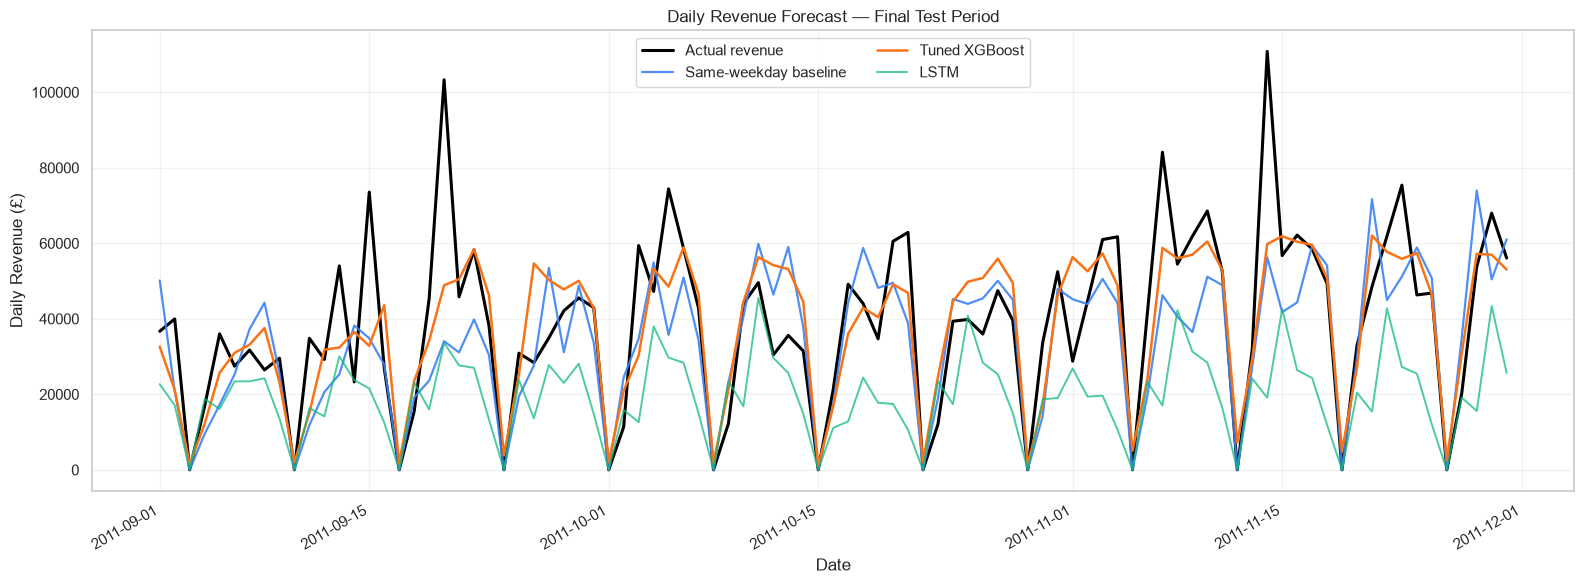

Saved: c:\Github\retail-financial-intelligence\reports\figures\revenue_forecasting


In [177]:
test_predictions["ForecastDate"] = pd.to_datetime(
    test_predictions["ForecastDate"],
    errors="raise"
)

fig, ax = plt.subplots(
    figsize=(16, 6)
)

ax.plot(
    test_predictions["ForecastDate"],
    test_predictions["ActualRevenue"],
    label="Actual revenue",
    color="black",
    linewidth=2.2
)

ax.plot(
    test_predictions["ForecastDate"],
    test_predictions["BaselinePrediction"],
    label="Same-weekday baseline",
    color="#3B82F6",
    linewidth=1.6,
    alpha=0.9
)

ax.plot(
    test_predictions["ForecastDate"],
    test_predictions["XGBoostPrediction"],
    label="Tuned XGBoost",
    color="#F97316",
    linewidth=1.8
)

ax.plot(
    test_predictions["ForecastDate"],
    test_predictions["LSTMPrediction"],
    label="LSTM",
    color="#10B981",
    linewidth=1.4,
    alpha=0.75
)

ax.set_title(
    "Daily Revenue Forecast — Final Test Period"
)

ax.set_xlabel("Date")
ax.set_ylabel("Daily Revenue (£)")

ax.legend(
    frameon=True,
    ncol=2
)

ax.grid(
    alpha=0.25
)

fig.autofmt_xdate()
fig.tight_layout()

plt.savefig(
    forecasting_figure_dir / "forecast_test_comparison.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white")

plt.show()

print("Saved:",forecasting_figure_dir)

In [164]:
comparison_records = []

for model_name, prediction_column in (
    prediction_columns.items()
):
    model_metrics = calculate_forecast_metrics(
        actual=test_predictions["ActualRevenue"],
        predicted=test_predictions[prediction_column]
    )

    comparison_records.append({
        "Model": model_name,
        **model_metrics
    })

forecast_model_comparison = pd.DataFrame(
    comparison_records
)

forecast_model_comparison["WAPERank"] = (
    forecast_model_comparison["WAPEPercent"]
    .rank(method="dense")
    .astype(int)
)

forecast_model_comparison = (
    forecast_model_comparison
    .sort_values("WAPERank")
    .reset_index(drop=True)
)

forecast_model_comparison.round(3)

,Model,Observations,MAE,RMSE,WAPEPercent,SMAPEPercent,BiasPercent,WAPERank
0,Tuned XGBoost Raw Target,91,9800.317,14121.721,25.287,51.345,-2.675,1
1,SameWeekday4WeekAverage,91,12068.298,16978.475,31.138,33.967,-12.418,2
2,LSTM 30-Day Sequence,91,20272.255,27115.922,52.306,85.758,-50.139,3


In [165]:
assert (
    forecast_model_comparison["Observations"] == 91
).all()

backtest_winner = (
    forecast_model_comparison
    .iloc[0]["Model"]
)

print("Backtest winner:", backtest_winner)

forecast_model_comparison.to_csv(
    forecast_artifacts["Model comparison"],
    index=False
)

Backtest winner: Tuned XGBoost Raw Target


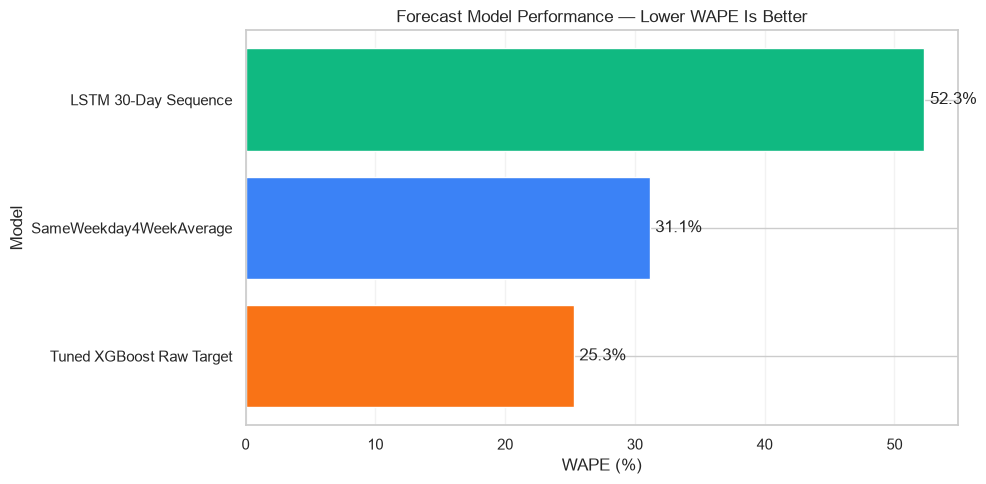

Saved: c:\Github\retail-financial-intelligence\reports\figures\revenue_forecasting


In [178]:
plot_comparison = (
    forecast_model_comparison
    .sort_values("WAPEPercent")
    .copy()
)

model_colours = [
    "#F97316"
    if model == "Tuned XGBoost Raw Target"
    else "#3B82F6"
    if model == "SameWeekday4WeekAverage"
    else "#10B981"
    for model in plot_comparison["Model"]
]

fig, ax = plt.subplots(
    figsize=(10, 5)
)

bars = ax.barh(
    plot_comparison["Model"],
    plot_comparison["WAPEPercent"],
    color=model_colours
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in plot_comparison[
            "WAPEPercent"
        ]
    ],
    padding=4
)

ax.set_title(
    "Forecast Model Performance — Lower WAPE Is Better"
)

ax.set_xlabel("WAPE (%)")
ax.set_ylabel("Model")

ax.grid(
    axis="x",
    alpha=0.25
)

fig.tight_layout()


fig.savefig(
    forecasting_figure_dir/"forecast_model_wape_comparison.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", forecasting_figure_dir)

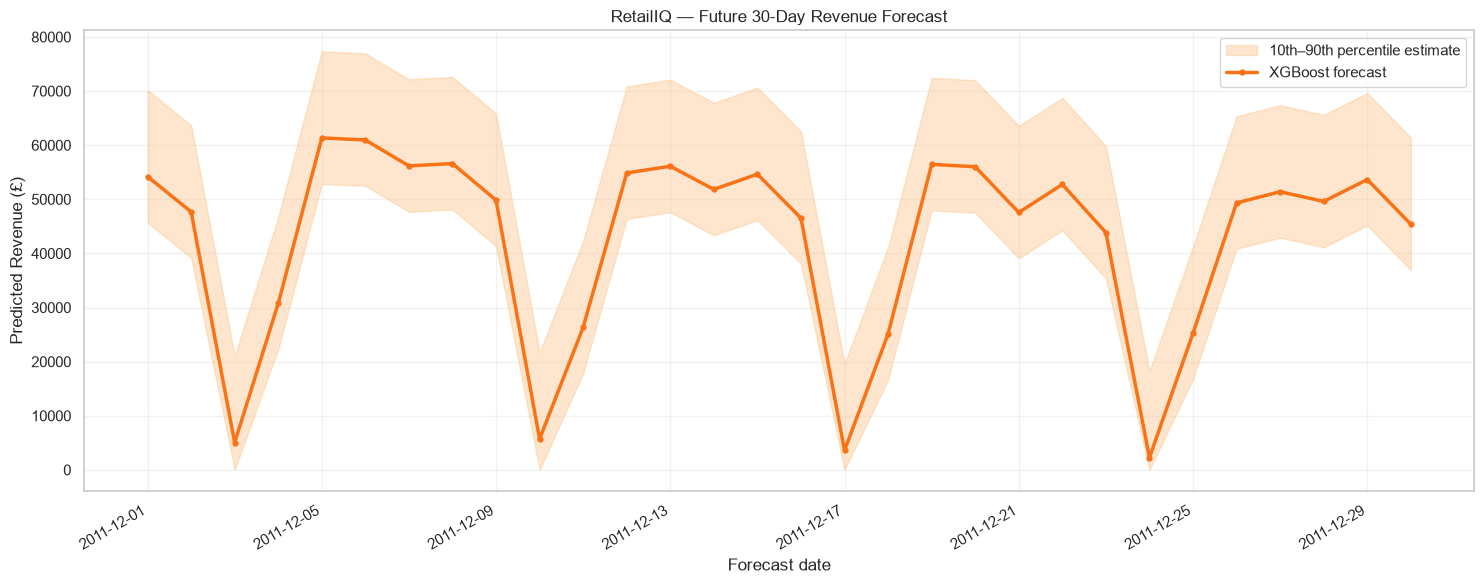

Saved: c:\Github\retail-financial-intelligence\reports\figures\revenue_forecasting


In [180]:
future_forecast["ForecastDate"] = pd.to_datetime(
    future_forecast["ForecastDate"],
    errors="raise"
)

fig, ax = plt.subplots(
    figsize=(15, 6)
)

ax.fill_between(
    future_forecast["ForecastDate"],
    future_forecast["LowerRevenueEstimate"],
    future_forecast["UpperRevenueEstimate"],
    color="#FDBA74",
    alpha=0.35,
    label="10th–90th percentile estimate"
)

ax.plot(
    future_forecast["ForecastDate"],
    future_forecast["PredictedRevenue"],
    color="#F97316",
    linewidth=2.5,
    marker="o",
    markersize=3.5,
    label="XGBoost forecast"
)

ax.set_title(
    "RetailIQ — Future 30-Day Revenue Forecast"
)

ax.set_xlabel("Forecast date")
ax.set_ylabel("Predicted Revenue (£)")

ax.legend(frameon=True)
ax.grid(alpha=0.25)

fig.autofmt_xdate()
fig.tight_layout()


fig.savefig(
    forecasting_figure_dir/"future_30_day_revenue_forecast.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", forecasting_figure_dir )

In [170]:
baseline_wape = (
    forecast_model_comparison
    .loc[
        forecast_model_comparison["Model"]
        == "SameWeekday4WeekAverage",
        "WAPEPercent"
    ]
    .iloc[0]
)

xgboost_wape = (
    forecast_model_comparison
    .loc[
        forecast_model_comparison["Model"]
        == "Tuned XGBoost Raw Target",
        "WAPEPercent"
    ]
    .iloc[0]
)

xgboost_improvement = (
    (baseline_wape - xgboost_wape)
    / baseline_wape
    * 100
)

forecast_metadata.update({
    "test_observations": int(
        len(test_predictions)
    ),
    "backtest_winner": (
        "Tuned XGBoost Raw Target"
    ),
    "selected_model": (
        "Tuned XGBoost Raw Target"
    ),
    "deployment_model": (
        "Tuned XGBoost Raw Target"
    ),
    "primary_selection_metric": (
        "WAPEPercent"
    ),
    "baseline_model": (
        "SameWeekday4WeekAverage"
    ),
    "wape_improvement_over_baseline_percent": round(
        xgboost_improvement,
        3
    ),
    "future_forecast_model": (
        "Tuned XGBoost Recursive Forecast"
    ),
    "future_forecast_role": (
        "Operational 30-day forecast"
    ),
    "model_selection_note": (
        "XGBoost achieved the best WAPE, MAE, RMSE "
        "and absolute bias on the final 91-day test "
        "period. The same-weekday model remains the "
        "business baseline."
    ),
    "currency": "GBP"
})

with open(
    forecast_artifacts["Forecast metadata"],
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        forecast_metadata,
        metadata_file,
        indent=4
    )

In [171]:
# Reload and validate the saved forecast metadata

with open(
    forecast_artifacts["Forecast metadata"],
    "r",
    encoding="utf-8"
) as metadata_file:
    saved_forecast_metadata = json.load(
        metadata_file
    )

validation_results = pd.Series({
    "Selected model": (
        saved_forecast_metadata["selected_model"]
    ),
    "Backtest winner": (
        saved_forecast_metadata["backtest_winner"]
    ),
    "Test observations": (
        saved_forecast_metadata["test_observations"]
    ),
    "WAPE improvement over baseline (%)": (
        saved_forecast_metadata[
            "wape_improvement_over_baseline_percent"
        ]
    ),
    "Future forecast model": (
        saved_forecast_metadata[
            "future_forecast_model"
        ]
    ),
    "Currency": (
        saved_forecast_metadata["currency"]
    )
})

validation_results

Selected model                                Tuned XGBoost Raw Target
Backtest winner                               Tuned XGBoost Raw Target
Test observations                                                   91
WAPE improvement over baseline (%)                              18.793
Future forecast model                 Tuned XGBoost Recursive Forecast
Currency                                                           GBP
dtype: object

In [172]:
assert (
    saved_forecast_metadata["selected_model"]
    == "Tuned XGBoost Raw Target"
)

assert (
    saved_forecast_metadata["backtest_winner"]
    == "Tuned XGBoost Raw Target"
)

assert (
    saved_forecast_metadata["test_observations"]
    == 91
)

assert (
    saved_forecast_metadata["currency"]
    == "GBP"
)

assert len(test_predictions) == 91
assert len(future_forecast) == 30

assert (
    forecast_model_comparison
    .iloc[0]["Model"]
    == "Tuned XGBoost Raw Target"
)

print("All forecast artifact validations passed.")

All forecast artifact validations passed.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd


# ---------------------------------------------------------
# 1. Locate the project
# ---------------------------------------------------------

current_directory = Path.cwd().resolve()

if current_directory.name.lower() == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

master_file = (
    project_root
    / "data"
    / "processed"
    / "retailiq_cleaned_master.csv.gz"
)

test_predictions_file = (
    project_root
    / "reports"
    / "tables"
    / "forecast_test_predictions.csv"
)


# ---------------------------------------------------------
# 2. Load the forecast test results
# ---------------------------------------------------------

forecast_test_predictions = pd.read_csv(
    test_predictions_file,
    parse_dates=["ForecastDate"]
)

required_prediction_columns = {
    "ForecastDate",
    "ActualRevenue"
}

missing_prediction_columns = (
    required_prediction_columns
    - set(forecast_test_predictions.columns)
)

if missing_prediction_columns:
    raise KeyError(
        "Missing prediction columns: "
        f"{sorted(missing_prediction_columns)}"
    )

forecast_test_predictions["ActualRevenue"] = (
    pd.to_numeric(
        forecast_test_predictions["ActualRevenue"],
        errors="raise"
    )
)

forecast_test_predictions = (
    forecast_test_predictions
    .sort_values("ForecastDate")
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 3. Actual revenue in the untouched forecast test period
# ---------------------------------------------------------

test_start = (
    forecast_test_predictions["ForecastDate"].min()
)

test_end = (
    forecast_test_predictions["ForecastDate"].max()
)

test_observations = (
    forecast_test_predictions["ForecastDate"].nunique()
)

actual_test_revenue = float(
    forecast_test_predictions["ActualRevenue"].sum()
)

print("Test start:", test_start.date())
print("Test end:", test_end.date())
print("Test observations:", test_observations)
print(
    "Actual test-period revenue:",
    f"£{actual_test_revenue:,.2f}"
)

assert test_start == pd.Timestamp("2011-09-01")
assert test_end == pd.Timestamp("2011-11-30")
assert test_observations == 91

Test start: 2011-09-01
Test end: 2011-11-30
Test observations: 91
Actual test-period revenue: £3,526,888.10


In [2]:
# ---------------------------------------------------------
# 4. Load the cleaned transaction master
# ---------------------------------------------------------

master_df = pd.read_csv(
    master_file,
    low_memory=False
)

required_master_columns = {
    "InvoiceDate",
    "Revenue",
    "TransactionType"
}

missing_master_columns = (
    required_master_columns
    - set(master_df.columns)
)

if missing_master_columns:
    raise KeyError(
        "Missing master columns: "
        f"{sorted(missing_master_columns)}"
    )

master_df["InvoiceDate"] = pd.to_datetime(
    master_df["InvoiceDate"],
    errors="raise"
)

master_df["Revenue"] = pd.to_numeric(
    master_df["Revenue"],
    errors="coerce"
)

master_df["TransactionType"] = (
    master_df["TransactionType"]
    .astype("string")
    .str.strip()
)


# ---------------------------------------------------------
# 5. Define the complete 24-month period
#    December 2009 through November 2011
# ---------------------------------------------------------

analysis_start = pd.Timestamp("2009-12-01")
analysis_end_exclusive = pd.Timestamp("2011-12-01")

two_year_mask = (
    master_df["InvoiceDate"].ge(analysis_start)
    &
    master_df["InvoiceDate"].lt(
        analysis_end_exclusive
    )
)

two_year_df = master_df.loc[
    two_year_mask
].copy()

sale_mask = (
    two_year_df["TransactionType"].eq("Sale")
)

cancellation_mask = (
    two_year_df["TransactionType"].eq(
        "Cancellation"
    )
)


# ---------------------------------------------------------
# 6. Calculate the revenue definitions
# ---------------------------------------------------------

gross_sales_revenue = float(
    two_year_df.loc[
        sale_mask,
        "Revenue"
    ].sum()
)

cancellation_impact = float(
    two_year_df.loc[
        cancellation_mask,
        "Revenue"
    ].sum()
)

net_product_sales_revenue = float(
    two_year_df.loc[
        sale_mask | cancellation_mask,
        "Revenue"
    ].sum()
)

all_recorded_line_revenue = float(
    two_year_df["Revenue"].sum()
)


# ---------------------------------------------------------
# 7. Reconcile test revenue with the master dataset
# ---------------------------------------------------------

master_test_mask = (
    master_df["InvoiceDate"].ge(test_start)
    &
    master_df["InvoiceDate"].lt(
        test_end + pd.Timedelta(days=1)
    )
)

master_test_sales_revenue = float(
    master_df.loc[
        master_test_mask
        &
        master_df["TransactionType"].eq("Sale"),
        "Revenue"
    ].sum()
)

forecast_matches_master = np.isclose(
    actual_test_revenue,
    master_test_sales_revenue,
    atol=0.01
)


# ---------------------------------------------------------
# 8. Present the summary
# ---------------------------------------------------------

revenue_summary = pd.DataFrame(
    {
        "Metric": [
            "Forecast target actual revenue",
            "Master gross sales revenue",
            "Gross product sales — complete 24 months",
            "Cancellation impact — complete 24 months",
            "Net product sales — complete 24 months",
            "All recorded line revenue — complete 24 months"
        ],
        "Period": [
            "2011-09-01 to 2011-11-30",
            "2011-09-01 to 2011-11-30",
            "2009-12-01 to 2011-11-30",
            "2009-12-01 to 2011-11-30",
            "2009-12-01 to 2011-11-30",
            "2009-12-01 to 2011-11-30"
        ],
        "ValueGBP": [
            actual_test_revenue,
            master_test_sales_revenue,
            gross_sales_revenue,
            cancellation_impact,
            net_product_sales_revenue,
            all_recorded_line_revenue
        ]
    }
)

revenue_summary["FormattedGBP"] = (
    revenue_summary["ValueGBP"]
    .map(lambda value: f"£{value:,.2f}")
)

display(
    revenue_summary[
        [
            "Metric",
            "Period",
            "FormattedGBP"
        ]
    ]
)

print(
    "Forecast actual matches master gross sales:",
    bool(forecast_matches_master)
)

,Metric,Period,FormattedGBP
0,Forecast target actual revenue,2011-09-01 to 2011-11-30,"£3,526,888.10"
1,Master gross sales revenue,2011-09-01 to 2011-11-30,"£3,583,825.33"
2,Gross product sales — complete 24 months,2009-12-01 to 2011-11-30,"£19,031,255.41"
3,Cancellation impact — complete 24 months,2009-12-01 to 2011-11-30,"£-555,401.72"
4,Net product sales — complete 24 months,2009-12-01 to 2011-11-30,"£18,475,853.69"
5,All recorded line revenue — complete 24 months,2009-12-01 to 2011-11-30,"£18,422,814.64"


Forecast actual matches master gross sales: False


In [3]:
revenue_summary_file = (
    project_root
    / "reports"
    / "tables"
    / "revenue_period_summary.csv"
)

revenue_summary.to_csv(
    revenue_summary_file,
    index=False
)

print("Saved:", revenue_summary_file)

Saved: C:\Github\retail-financial-intelligence\reports\tables\revenue_period_summary.csv


In [183]:
from pathlib import Path
import sys

current_path = Path.cwd().resolve()
project_root = None

for candidate in [
    current_path,
    *current_path.parents
]:
    if (candidate / "dashboard").is_dir():
        project_root = candidate
        break

if project_root is None:
    raise FileNotFoundError(
        "Could not locate the RetailIQ project root."
    )

project_root_string = str(project_root)

if project_root_string not in sys.path:
    sys.path.insert(
        0,
        project_root_string
    )

print("Project root:", project_root)
print(
    "Dashboard folder found:",
    (project_root / "dashboard").is_dir()
)

Project root: C:\Github\retail-financial-intelligence
Dashboard folder found: True


In [186]:
import importlib

import dashboard.utils.data_loader as data_loader

importlib.reload(data_loader)

print("Dashboard data loader imported successfully.")

2026-09-13 15:07:03.719 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:07:03.721 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:07:03.722 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:07:03.725 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:07:03.728 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:07:03.731 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:07:03.734 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:07:03.736 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-

Dashboard data loader imported successfully.


In [185]:
import importlib
from pathlib import Path

import dashboard.utils.data_loader as data_loader

importlib.reload(data_loader)

forecast_comparison = (
    data_loader.load_forecast_model_comparison()
)

forecast_test = (
    data_loader.load_forecast_test_predictions()
)

future_forecast = (
    data_loader.load_future_revenue_forecast()
)

forecast_metadata = (
    data_loader.load_forecast_metadata()
)

print(
    "Comparison:",
    forecast_comparison.shape
)

print(
    "Test predictions:",
    forecast_test.shape
)

print(
    "Future forecast:",
    future_forecast.shape
)

print(
    "Selected model:",
    forecast_metadata["selected_model"]
)

2026-09-13 15:06:51.708 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:06:51.717 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:06:51.720 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:06:51.721 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:06:51.722 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:06:51.724 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:06:51.727 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-09-13 15:06:51.729 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:06:51.732 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:06:51.734 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:06:51.735 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:06:51.737 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:06:51.739 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:06:51.740 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:06:51.742 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-

Comparison: (3, 8)
Test predictions: (91, 5)
Future forecast: (30, 6)
Selected model: Tuned XGBoost Raw Target


In [190]:
import importlib
import inspect

import dashboard.utils.data_loader as data_loader

importlib.reload(data_loader)

available_loaders = [
    name
    for name, function in inspect.getmembers(
        data_loader,
        inspect.isfunction
    )
    if (
        name.startswith("load_")
        or name.startswith("get_")
    )
]

print("Available dashboard loaders:\n")

for loader_name in available_loaders:
    print(loader_name)

2026-09-13 15:33:15.134 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:33:15.148 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:33:15.151 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:33:15.156 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:33:15.158 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:33:15.164 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:33:15.169 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-13 15:33:15.173 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-09-

Available dashboard loaders:

get_forecast_model_wape_figure_path
get_forecast_test_figure_path
get_future_forecast_figure_path


In [191]:
required_recommendation_loaders = [
    "load_customer_segments",
    "load_customer_cluster_profile",
    "load_product_lifecycle",
    "load_market_basket_rules",
    "load_market_basket_summary",
    "load_anomaly_invoice_cases",
    "load_anomaly_case_summary",
    "load_anomaly_monthly_metrics",
    "load_forecast_model_comparison",
    "load_forecast_test_predictions",
    "load_future_revenue_forecast",
    "load_forecast_metadata"
]

loader_check = {
    loader_name: hasattr(
        data_loader,
        loader_name
    )
    for loader_name in (
        required_recommendation_loaders
    )
}

loader_check

{'load_customer_segments': True,
 'load_customer_cluster_profile': True,
 'load_product_lifecycle': True,
 'load_market_basket_rules': True,
 'load_market_basket_summary': True,
 'load_anomaly_invoice_cases': True,
 'load_anomaly_case_summary': True,
 'load_anomaly_monthly_metrics': True,
 'load_forecast_model_comparison': True,
 'load_forecast_test_predictions': True,
 'load_future_revenue_forecast': True,
 'load_forecast_metadata': True}